# Import

In [88]:
# Here import the necessary Python packages

import os
import sys
import time
import ansys.aedt.core
from ansys.aedt.core import Hfss

import numpy as np
import scipy.constants as C
from scipy.optimize import fsolve
import random

import csv
import pandas as pd

# progress bar
from rich.progress import track
# text color
from termcolor import colored
# copy
import shutil 
# plot
import matplotlib.pyplot as plt

# run SSH in jupyter notebook
import subprocess

# 1 Simulation Initialization

## 1.1 Input Parameter Setting

In [19]:
# Input Parameter Panel
# All the input parameters of the workflow are here, except the device layout design
# If use frequency matching, put single_frequency = 0 
# If import external .gds, put impot_file = 1


# I.Superconductivity Parameters
#     a). Primary Phase (alpha phase)
alpha_Tc = 2.8                                                 # Critical temperature. Unit:K
alpha_BCS_Ratio = 1.8                                          # BCS gap ratio. Unit:1
alpha_London = 225                                             # London penetration depth at 0 temperature. Unit:Angstrom
alpha_Coherence = 3200                                          # Coherence length at 0 temperature. Unit:Angstrom
alpha_RRR = 100                                                # Residual resistance ratio. Unit:1
alpha_Filling = 1                                            # Filling factor. Unit:1
alpha_Error = 0.001                                              # Numerical error. Unit:1
#     b). Secondary Phase (beta phase)
beta_Tc = 2.8                                                  # Critical temperature. Unit:K
beta_BCS_Ratio = 0.8                                           # BCS gap ratio. Unit:1
beta_London = 225                                              # London penetration depth at 0 temperature. Unit:Angstrom
beta_Coherence = 3200                                           # Coherence length at 0 temperature. Unit:Angstrom
beta_RRR = 100                                                 # Residual resistance ratio. Unit:1
beta_Filling = 1                                             # Filling factor. Unit:1
beta_Error = 0.001                                               # Numerical error. Unit:1
#     c). Concentration
beta_concentration = 0.05


# II. Temperature and Frequency Range      
#     a). Temperature Range
ini_temp = 1.0                                               # Initial temperature of the temperature range, Unit:K                    
fin_temp = 2.0                                               # Final temperature of the temperature range, Unit:K                    
step_t = 3                                                  # Temperature steps               
temp_space = np.linspace(ini_temp, fin_temp, step_t)
#     b). Frequaency Range
# single_frequency = 0                                         # Whether to use frequency matching. If use frequency matching: single_frequency = 0
single_frequency = 1
freq_mateched = 0
ini_freq = 5.0                                               # Initial frequency of the temperature range, Unit:GHz 
fin_freq = 6.0                                               # Final frequency of the temperature range, Unit:GHz 
step_f = 3                                                   # Frequency steps 
freq_space = np.linspace(ini_freq, fin_freq, step_f)
eigen_frequency = 5.5                                        # Single frequency, Unit:GHz


# III. Paths and Filenames
main_dir = 'C:\\Users\\65751\\Documents\\HFSS_files\\'
date = '2025_06_26\\'
alpha_Tc_N = 'ATc_'+str(alpha_Tc)+'K_'
beta_Tc_N = 'BTc_'+str(beta_Tc)+'K\\'
beta_con = str(beta_concentration*100)+'per_Beta\\'


# IV. GDS File Import 
# impot_file = 0                                             # Whether to import GDS file. If import GDS file: impot_file = 1
impot_file = 1
gds_file = "C:\\Users\\65751\\Downloads\\diluted_resonator.GDS" 
layer_namber = 3
thickness = 0
elevation = 0


# V. PyAEDT Parameters
#     a). PyAEDT Instance Parameters
template_aedt_name = 'template_file'
HFSS_version="2023.2"
design_name="Design01"                                       #Usually use this default name
#     b). HFSS Simulation Setup
setup_name ="Setup_01"                                       # Usually use this default name 
MinimumFrequency="2GHz"                                      # The starting frequency of the frequency sweep
NumModes = 1                                                 # The number of eigenfrequencies to find
MaximumPasses=20                                             # Number of maximum passes
MaxDeltaFreq=1                                               # Maximum delta frequency
PercentRefinement=20                                         # Maximum percent refinement of each pass
MinimumConvergedPasses=2                                     # Minimum converged passes
MinimumPasses=2                                              # Minimum Passes
#     c). Length unit
length_unit = "um"
#     d). Vacuum and substrate parameters
vac_length = 10000                                           # Vacuum length. Unit:um                                          
vac_height = 10000                                           # Vacuum height. Unit:um
sub_length = 7000                                            # Vacuum substrate. Unit:um
sub_height = 330                                             # Vacuum substrate. Unit:um
#     e). Meshing Parameters
# resonator_mesh_box = 1                                     # Whether to use mesh box for resonator. If use mesh box: resonator_mesh_box = 1
resonator_mesh_box = 0
mesh_box_length = 2000                                       # Mesh box length. Unit:um 
box_max_mesh_len = 100                                       # Mesh box length. Unit:um 
substrate_max_mesh_len = 10                                   # Maximum mesh length of substrate. Unit:um
alpha_max_mesh_len = 10                                      # Maximum mesh length of the primary (alpha) phase of the resonator. Unit:um
beta_max_mesh_len = 10                                       # Maximum mesh length of the secondary (beta) phase of the resonator. Unit:um


# VI. Chessboard Grid Parameters
mesh_grid_dimension = 100                                    # Unit:um
chess_board_length = 1000                                    # Unit:um
concentration_deviation_condition = 0.8

# Batch Generation
sleep_time = 8                                               # Second

## 1.2 Path Generation

In [3]:
class create_path:
    def different_Tc(alpha_Tc, beta_Tc):
        save_path_0 = main_dir+date
        save_path_00 = main_dir+date+beta_con
        save_path_1 = main_dir+date+beta_con++'aTc_'+str(alpha_Tc)++'aTc_'+str(beta_Tc)+'\\'
        path_exist = str(os.path.exists(save_path_0))
        if path_exist == 'False':
            os.mkdir(save_path_0)
            print('create path')
        else:
            print('save_date exists')  
        path_exist = str(os.path.exists(save_path_00))
        if path_exist == 'False':
            os.mkdir(save_path_00)
            print('create path')
        else:
            print('save_date exists')
        path_exist = str(os.path.exists(save_path_1))
        if path_exist == 'False':
            os.mkdir(save_path_1)
            print('create path')
        else:
            print('save_folder exists')   
    
        return save_path_1


    def different_BCS_ratio(alpha_BCS_Ratio, beta_BCS_Ratio):
        save_path_0 = main_dir+date
        save_path_00 = main_dir+date+beta_con
        save_path_1 = main_dir+date+beta_con+'aBCS_'+str(alpha_BCS_Ratio)+'_bBCS_'+str(beta_BCS_Ratio)+'\\'
        path_exist = str(os.path.exists(save_path_0))
        if path_exist == 'False':
            os.mkdir(save_path_0)
            print('create path')
        else:
            print('save_date exists')  
        path_exist = str(os.path.exists(save_path_00))
        if path_exist == 'False':
            os.mkdir(save_path_00)
            print('create path')
        else:
            print('save_date exists')
        path_exist = str(os.path.exists(save_path_1))
        if path_exist == 'False':
            os.mkdir(save_path_1)
            print('create path')
        else:
            print('save_folder exists')   
    
        return save_path_1


    def different_London(alpha_London, beta_London):
        save_path_0 = main_dir+date
        save_path_00 = main_dir+date+beta_con
        save_path_1 = main_dir+date+beta_con+'aLondon_'+str(alpha_London)+'_bLondon_'+str(beta_London)+'\\'
        path_exist = str(os.path.exists(save_path_0))
        if path_exist == 'False':
            os.mkdir(save_path_0)
            print('create path')
        else:
            print('save_date exists')  
        path_exist = str(os.path.exists(save_path_00))
        if path_exist == 'False':
            os.mkdir(save_path_00)
            print('create path')
        else:
            print('save_date exists')
        path_exist = str(os.path.exists(save_path_1))
        if path_exist == 'False':
            os.mkdir(save_path_1)
            print('create path')
        else:
            print('save_folder exists')   
    
        return save_path_1


    def different_Coherence(alpha_Coherence, beta_Coherence):
        save_path_0 = main_dir+date
        save_path_00 = main_dir+date+beta_con
        save_path_1 = main_dir+date+beta_con+'aCoherence_'+str(alpha_Coherence)+'_bCoherence_'+str(beta_Coherence)+'\\'
        path_exist = str(os.path.exists(save_path_0))
        if path_exist == 'False':
            os.mkdir(save_path_0)
            print('create path')
        else:
            print('save_date exists')  
        path_exist = str(os.path.exists(save_path_00))
        if path_exist == 'False':
            os.mkdir(save_path_00)
            print('create path')
        else:
            print('save_date exists')
        path_exist = str(os.path.exists(save_path_1))
        if path_exist == 'False':
            os.mkdir(save_path_1)
            print('create path')
        else:
            print('save_folder exists')   
    
        return save_path_1


    def different_RRR(alpha_RRR, beta_RRR):
        save_path_0 = main_dir+date
        save_path_00 = main_dir+date+beta_con
        save_path_1 = main_dir+date+beta_con+'aRRR_'+str(alpha_RRR)+'_bRRR_'+str(beta_RRR)+'\\'
        path_exist = str(os.path.exists(save_path_0))
        if path_exist == 'False':
            os.mkdir(save_path_0)
            print('create path')
        else:
            print('save_date exists')  
        path_exist = str(os.path.exists(save_path_00))
        if path_exist == 'False':
            os.mkdir(save_path_00)
            print('create path')
        else:
            print('save_date exists')
        path_exist = str(os.path.exists(save_path_1))
        if path_exist == 'False':
            os.mkdir(save_path_1)
            print('create path')
        else:
            print('save_folder exists')   
    
        return save_path_1

In [4]:
save_path_1 = create_path.different_BCS_ratio(alpha_BCS_Ratio, beta_BCS_Ratio)

create path
create path
create path


# 2 Mattis-Bardeen Simulation

## 2.1 Mattis-Berdeen Model

In [5]:
# Mattis-Bardeen model function
# In our simulation we mainly consider electron diffusive scattering condition, so the specular scattering condition output is deactivated
# Real part output penetration depth is replaced by surface reactance

# define physics constants
k_b = C.k
m_0 = C.m_e
miu_0 = C.mu_0
hbar = C.hbar
q = C.e
eV = C.electron_volt
pi = np.pi
c = C.c
eps_0 = C.epsilon_0


# Mattis-Bardeen code translate from Fortran

def Q_QPs(FO, TC, FAK, DLON, XKOH, RRR, REST, TE, Alpha):
    global RD,SurImp,InD,XD,ENP,London_Pen_T,Qi_QPs
    
    FO=float(FO)
    FO=FO*10**9
    TC=float(TC)
    FAK=float(FAK)
    DLON=float(DLON)
    XKOH=float(XKOH)
    RRR=float(RRR)
    FREI=66*RRR
    #FREI=float(FREI)
    REST=float(REST)
    TE=float(TE)
    srimp(FO, TC, FAK, DLON, XKOH, FREI, REST, TE, Alpha)
    return XD, RD, London_Pen_T, Qi_QPs

#def srimp(FO, TC, FAK, DLON, XKOH, RRR, FREI, REST, TE, Alpha):
def srimp(FO, TC, FAK, DLON, XKOH, FREI, REST, TE, Alpha):
    
    global ID,IQ,MS,IS,IP,AK,A2,FL,O,GP,DQ,DX,DQ1,DS,CHS,CHD,CI,CDS,CT,CS,CD
    global RD,SurImp,InD,XD,ENP,London_Pen_T,Qi_QPs
    ###################
    G=np.zeros(6)
    ID=np.zeros(6)
    DQ=np.zeros(6)
    DX=np.zeros(10000)
    DS=np.zeros(10000)
    CDS=np.zeros(10000,dtype=complex)
    CT=np.zeros(10000,dtype=complex)
    ###################
    
    G=np.array([1e-6, 1e-2, 0.2, 2.0, 5.0, 50.0])
    PH=0.479*10**-10
    IS=np.floor((6.0*.0001/REST)**0.25+1.0)
    CI=complex(0,1)
    FLO=XKOH/FREI
    AL=DLON/XKOH
    OG=PH*FO/TC/FAK
    ID=np.array([5*IS, 7*IS, 15*IS, 20*IS, 20*IS, 9*IS])
    DX=np.zeros(10000) 
    DQ=np.zeros(6) 
    
    setDX(G)
    
    T=TE/TC
    B=np.pi/2.0*(1.0-T*T)
    AG=np.sqrt(np.sin(B))
    FL=FLO/AG
    O=OG/AG
    
    if O<0.5:
        GP=AG/T*FAK
        IS=np.floor(1.0/np.sqrt(O*REST)/5.0)
        IP=np.floor(1.0/np.sqrt((2.0-O)*REST)/5.0)
        
        for i in range(0,IQ+1):
            ###################
            #global 
            #DS=np.zeros(10000)
            ###################
            DS[i]=0
            CDS[i]=0
            
        nonan()
        
        MS=np.floor(GP/(np.sqrt(REST)*2.0*np.pi))
        
        isum()
        
        DQ1=abs(CDS[0])
        ENP=1.0/np.sqrt(DQ1)
        AK=AL*ENP*AG
        A2=AK*AK
        
        haupt()
        
        CHS=CHS*ENP
        CHD=CHD*ENP
        lambdas=np.real(CHS)*DLON
        lambdad=np.real(CHD)*DLON
        
        XS=lambdas*(FO*2*np.pi/np.power(10.0,17))*np.pi*4
        XD=lambdad*(FO*2*np.pi/np.power(10.0,17))*np.pi*4
        
        B=(FO/np.power(10.0,17))*8.0*np.pi*np.pi*DLON
        
        RS=np.imag(CHS)*B
        RD=np.imag(CHD)*B
        ################################
        SurImp=CHD*B
        InD=np.real(CHD)*B
        London_Pen_T=np.real(CHD)*DLON
        
        if RD==0:
            RD=10**(-250)
            Qi_QPs0=10**250
        else:
            Qi_QPs0=XD/RD
       
        Qi_QPs= Qi_QPs0/Alpha
        
        
def setDX(G):
    
    global ID,IQ,MS,IS,IP,AK,A2,FL,O,GP,DQ,DX,DQ1,DS,CHS,CHD,CI,CDS,CT,CS,CD
    ################################
    DX[0]=0
    DX[1]=G[0]
    IQ=1
    
    for N in range(0,4+1):
        LL=ID[N]-1
        D=ID[N]*2
        ID[N]=LL
        DA=G[N]
        DZ=G[N+1]
        DELT=(DZ-DA)/D
        DET=DELT*2
        DQ[N]=DELT/3
        for K in range(1,int(LL+1)):
            DA=DA+DET
            DE=DA-DELT
            IQ=IQ+1
            DX[IQ]=DE
            IQ=IQ+1
            DX[IQ]=DA
        DE=DZ-DELT
        IQ=IQ+1
        DX[IQ]=DE
        IQ=IQ+1
        DX[IQ]=DZ
        
    LL=ID[5]-1
    D=ID[5]*2
    ID[5]=LL
    DA=G[0]
    DZ=1/G[5]
    DELT=(DZ-DA)/D
    DET=DELT*2
    DQ[5]=DELT/3
    IQ=IQ+1
    DX[IQ]=1/DA
    
    for K in range(1,int(LL+1)):
        DA=DA+DET
        DE=DA-DELT
        IQ=IQ+1
        DX[IQ]=1/DE
        IQ=IQ+1
        DX[IQ]=1/DA
        
    DE=DZ-DELT
    IQ=IQ+1
    DX[IQ]=1/DE
    IQ=IQ+1
    DX[IQ]=1/DZ
    
    
def nonan():
    
    global ID,IQ,MS,IS,IP,AK,A2,FL,O,GP,DQ,DX,DQ1,DS,CHS,CHD,CI,CDS,CT,CS,CD
    ################################
    OT=O/2.0*GP
    
    if OT<=0.2:
        O2=OT*OT
        DV=(
            OT*(1.0+O2/6.0*(1.0+O2/20.0*(1.0+O2/42.0*
            (1.0+O2/72.0*(1.0+O2/110.0)))))*np.exp(-OT)
        )
        OT=-OT*2.0
    else:
        OT=-OT*2.0
        DV=(1.0-np.exp(OT))/2.0
        
    B=4.0*IS    
    BS=np.pi/B
    
    for K in range(1,int(IS+1)):
        B=4.0*(IS-K)+2
        D=B*BS
        DZ=0.5*(1.0+np.cos(D))
        DU=GP/DZ
        DA=np.exp(-DU)
        DG=np.exp(-DU+OT)
        DC=DA/((1.0+DG)*(1.0+DA))*DV
        DP=DZ+1.0
        DP=DZ+1.0
        DM=1.0-DZ
        DU=DP*DM
        DW=np.sqrt(DU)
        DA=DZ*O
        DWO=np.sqrt(DU+DA*(2.0+DA))
        DP=DZ*np.sqrt(DZ*DP)
        DU=DA/DU
        
        if DU<=0.1:
            DU=DU*(2.0+DA)/2.0
            DM=(
                DU*(1.0-0.5*DU*(1.0-DU*(1.0-1.25*DU*(1.0-1.4*
                DU*(1.0-1.5*DU*(1.0-11.0*DU/7.0*(1.0-1.5*
                DU*(1.0-13.0*DU/9.0*(1.0-1.4*DU)))))))))*DW
            )
        else:
            DM=DWO-DW
        
        CY=complex(FL,-DM/2/DZ) 
        
        wink(CY)
        DU=DC/DP/DWO
        DWU=DWO*DW
        DM=1.0+DZ*(DZ+O)
        DPS=(DM+DWU)*DU
        DMS=(DM-DWU)*DU
        
        for i in range(0,IQ+1):
            CDS[i]=CDS[i]+DPS*CT[i]
            
        DM=DWO+DW
        CY=complex(FL,DM/2/DZ)
        
        wink(CY)
        
        for i in range(0,IQ+1):
            DS[i]=np.real(DS[i]+DMS*CT[i])
    
    CY=complex(0,-4*BS)
    
    for i in range(0,IQ+1):
        CDS[i]=(CDS[i]+DS[i])*CY
        DS[i]=0
        
    B=4*IP
    BS=np.pi/B
    
    for K in range(1,int(IP+1)):
        B=4*(IP-K)+2
        D=B*BS
        DZ=1.0+0.5*O*(1.0+np.cos(D))
        DU=GP*DZ
        DA=np.exp(-DU)
        DG=np.exp(-DU-OT)
        DC=DG/((1.0+DG)*(1.0+DA))*DV
        DP=DZ+1.0
        DM=DZ-1.0
        DW=np.sqrt(DP*DM)
        DA=O-DM
        DU=DP-O
        DWO=np.sqrt(DA*DU)
        
        CY=complex(DWO+FL,DW)
        
        wink(CY)
        
        CY=complex((1.0+DZ*(DZ-O))/np.sqrt(DP*DU)*DC,DW*DWO/np.sqrt(DP*DU)*DC)
        
        for i in range(0,IQ+1):
            np.real(DS[i]+CY*CT[i])
    
    B=BS*4.0
    
    for i in range(0,IQ+1):
        CDS[i]=CDS[i]+DS[i]*B
        
            
            
def wink(CL):
    
    global ID,IQ,MS,IS,IP,AK,A2,FL,O,GP,DQ,DX,DQ1,DS,CHS,CHD,CI,CDS,CT,CS,CD
    ################################
    for I in range(0,IQ+1):
        
        D=DX[I]
        CD=D/CL 
        C2=CD*CD
        if abs(CD)<=0.2:
            x=np.real(C2)
            y=np.imag(C2)
            x2=(
                -np.power(x,7)/255+np.power(x,6)/195+(7*np.power(x,5)*y*y)/85
                -np.power(x,5)/143-(np.power(x,4)*y*y)/13+np.power(x,4)/99
                -(7*np.power(x,3)*np.power(y,4))/51+(10*np.power(x,3)*y*y)/143
                -np.power(x,3)/63+(x*x*np.power(y,4))/13-(2*x*x*y*y)/33+x*x/35
                +(7*x*np.power(y,6))/255-(5*x*np.power(y,4))/143+(x*y*y)/21-x/15
                -np.power(y,6)/195+np.power(y,4)/99-y*y/35+1/3
            )
            y2=(
                -(7*np.power(x,6)*y)/255+(2*np.power(x,5)*y)/65+(7*np.power(x,4)*np.power(y,3))/51
                -(5*np.power(x,4)*y)/143-(4*np.power(x,3)*np.power(y,3))/39+(4*np.power(x,3)*y)/99
                -(7*x*x*np.power(y,5))/85+(10*x*x*np.power(y,3))/143-(x*x*y)/21+(2*x*np.power(y,5))/65
                -(4*x*np.power(y,3))/99+(2*x*y)/35+np.power(y,7)/255-np.power(y,5)/143+np.power(y,3)/63
                -y/15
            )
            CL2=3/CL
            ########################
            np.real(CL2)
            complex(np.real(CL2),np.real(CL2))
            complex(x2,x2)
            ########################
            CT[I]=complex(np.real(CL2)*x2-np.imag(CL2)*y2,np.real(CL2)*y2+np.imag(CL2)*x2)
        else:
            CD=1/CD
            CT[I]=(0.75/D)*((np.log(CD+CI)-np.log(CD-CI))*((CD*CD+1)/CI)-2*CD)
            
            
def isum():
    
    global ID,IQ,MS,IS,IP,AK,A2,FL,O,GP,DQ,DX,DQ1,DS,CHS,CHD,CI,CDS,CT,CS,CD
    ################################
    G=np.pi/GP
    
    for i in range(0,IQ+1):
        DS[i]=0
    
    for M in range(1,int(MS+1)):
        B=2*(MS-M)+1
        B=B*G
        DU=B*B+1.0
        CB=complex(B,O)
        CU=CB*CB+1.0
        DW=np.sqrt(DU)
        CW=np.sqrt(CU)
        CL=(DW+CW)/2+FL
        CP=DW*CW
        CA=((1-B*CB)+CP)/CP
        
        wink(CL)
        
        for i in range(0,IQ+1):
            DS[i]=np.real(DS[i]+CA*CT[i])
        
    for i in range(0,IQ+1):
        CDS[i]=G*DS[i]+CDS[i]
        
        
def intq(L,M):
    
    global ID,IQ,MS,IS,IP,AK,A2,FL,O,GP,DQ,DX,DQ1,DS,CHS,CHD,CI,CDS,CT,CS,CD
    ################################
    CDG=CDS[L]/DQ1
    DX2=DX[L]*DX[L]
    DA=DX2*A2 
    
    if M==1:
        CS=1/(DA+CDG)
        CD=np.log(1.0+CDG/DA)
        
    elif M==2:
        CS=1/(A2+CDG/DX2)
        CD=DX2*np.log(1.0+CDG/DA)
        
    L=L+1
    return L



def haupt():
    
    global ID,IQ,MS,IS,IP,AK,A2,FL,O,GP,DQ,DX,DQ1,DS,CHS,CHD,CI,CDS,CT,CS,CD
    ################################
    ###############################
    global CID,CED,CAD,CD
    ###############################
    M=1
    I=1
    
    I=intq(I,M)
    
    CIS=DX[1]*CS
    CID=DX[1]*CD+2*DX[1]
    
    for J in range(0,5+1):
        
        if J>=5:
            M=2
            I=intq(I,M)
            CIS=CIS+CS*DX[1]
            CID=CID+CD*DX[1]
            
        CES=0.
        CED=0.
        CAS=0.5*CS
        CAD=0.5*CD
        LL=ID[J]
        
        for K in range(1,int(LL+1)):
            
            I=intq(I,M)
            
            CES=CES+CS
            CED=CED+CD
            
            I=intq(I,M)
            
            CAS=CAS+CS
            CAD=CAD+CD
            
        I=intq(I,M)
        
        CES=CES+CS
        CED=CED+CD
        
        I=intq(I,M)
        
        CIS=CIS+DQ[J]*(4*CES+2*CAS+CS)
        CID=CID+DQ[J]*(4*CED+2*CAD+CD)
        
    A=2.0/np.pi*AK
    CHS=A*CIS
    CHD=(2/A)/CID

## 2.2 Surface Impedance Calculation

In [6]:
# OOP Version

class calculate_impedance:

    def single_frequency():

        file_name = save_path_1+f_haed_name+'_Freq_Match.xlsx'
        df = pd.read_excel(file_name, sheet_name='Sheet1')
        frequency_df = df.iloc[0:, 1:]
        frequency_matrix = frequency_df.values*1e-9
        matched_f = frequency_matrix.reshape(1,-1)

        global ind_alpha, res_alpha
        ind_alpha = np.zeros(len(temp_space))
        res_alpha = np.zeros(len(temp_space))
        for i in track(range(len(temp_space)), description="Calculating alpha impedance..."):
            TE = temp_space[i]
            FO = eigen_frequency
            TC = alpha_Tc
            FAK = alpha_BCS_Ratio                                          
            DLON = alpha_London                                           
            XKOH = alpha_Coherence                                         
            RRR = alpha_RRR                                               
            Alpha = alpha_Filling                                            
            REST = alpha_Error  
            temp_result = Q_QPs(FO, TC, FAK, DLON, XKOH, RRR, REST, TE, Alpha)
            ind_alpha[i] = temp_result[0]
            res_alpha[i] = temp_result[1]
        
        global ind_beta, res_beta
        ind_beta = np.zeros(len(temp_space))
        res_beta = np.zeros(len(temp_space))
        for i in track(range(len(temp_space)), description="Calculating beta impedance..."):
            TE = temp_space[i]
            FO = eigen_frequency
            TC = beta_Tc
            FAK = beta_BCS_Ratio                                          
            DLON = beta_London                                           
            XKOH = beta_Coherence                                         
            RRR = beta_RRR                                               
            Alpha = beta_Filling                                            
            REST = beta_Error
            temp_result = Q_QPs(FO, TC, FAK, DLON, XKOH, RRR, REST, TE, Alpha) 
            ind_beta[i] = temp_result[0]
            res_beta[i] = temp_result[1]

        return ind_alpha, res_alpha, ind_beta, res_beta


    def single_frequency():
        global ind_alpha, res_alpha
        ind_alpha = np.zeros(len(temp_space))
        res_alpha = np.zeros(len(temp_space))
        for i in track(range(len(temp_space)), description="Calculating alpha impedance..."):
            TE = temp_space[i]
            FO = eigen_frequency
            TC = alpha_Tc
            FAK = alpha_BCS_Ratio                                          
            DLON = alpha_London                                           
            XKOH = alpha_Coherence                                         
            RRR = alpha_RRR                                               
            Alpha = alpha_Filling                                            
            REST = alpha_Error  
            temp_result = Q_QPs(FO, TC, FAK, DLON, XKOH, RRR, REST, TE, Alpha)
            ind_alpha[i] = temp_result[0]
            res_alpha[i] = temp_result[1]
        
        global ind_beta, res_beta
        ind_beta = np.zeros(len(temp_space))
        res_beta = np.zeros(len(temp_space))
        for i in track(range(len(temp_space)), description="Calculating beta impedance..."):
            TE = temp_space[i]
            FO = eigen_frequency
            TC = beta_Tc
            FAK = beta_BCS_Ratio                                          
            DLON = beta_London                                           
            XKOH = beta_Coherence                                         
            RRR = beta_RRR                                               
            Alpha = beta_Filling                                            
            REST = beta_Error
            temp_result = Q_QPs(FO, TC, FAK, DLON, XKOH, RRR, REST, TE, Alpha) 
            ind_beta[i] = temp_result[0]
            res_beta[i] = temp_result[1]

        return ind_alpha, res_alpha, ind_beta, res_beta


        
    def multiple_frequency():
        # alpha
        global ind_alpha, res_alpha
        ind_alpha = np.zeros(shape=(len(temp_space),len(freq_space)))
        res_alpha = np.zeros(shape=(len(temp_space),len(freq_space)))
        for i in track(range(len(temp_space)), description="Calculating alpha impedance..."):
            TE = temp_space[i]
            TC = alpha_Tc
            FAK = alpha_BCS_Ratio                                          
            DLON = alpha_London                                           
            XKOH = alpha_Coherence                                         
            RRR = alpha_RRR                                               
            Alpha = alpha_Filling                                            
            REST = alpha_Error
            for j in range(len(freq_space)):
                FO = freq_space[j]
                temp_result = Q_QPs(FO, TC, FAK, DLON, XKOH, RRR, REST, TE, Alpha)
                ind_alpha[i,j] = temp_result[0]
                res_alpha[i,j] = temp_result[1]
        
        # beta
        global ind_beta, res_beta
        ind_beta = np.zeros(shape=(len(temp_space),len(freq_space)))
        res_beta = np.zeros(shape=(len(temp_space),len(freq_space)))
        for i in track(range(len(temp_space)), description="Calculating beta impedance..."):
            TE = temp_space[i]
            TC = beta_Tc
            FAK = beta_BCS_Ratio                                          
            DLON = beta_London                                           
            XKOH = beta_Coherence                                         
            RRR = beta_RRR                                               
            Alpha = beta_Filling                                            
            REST = beta_Error
            for j in range(len(freq_space)):
                FO = freq_space[j]
                temp_result = Q_QPs(FO, TC, FAK, DLON, XKOH, RRR, REST, TE, Alpha)
                ind_beta[i,j] = temp_result[0]
                res_beta[i,j] = temp_result[1]

        return ind_alpha, res_alpha, ind_beta, res_beta


## 2.3 Result Plotting

In [7]:
# OOP Version

class plot_impedance:
    # def __init__(self, value=0):
    #     """
    #     Initialize the Calculator with an optional starting value.
    #     """
    #     self.value = value

    def single_frequency():
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        
        line1, = ax1.plot(temp_space,ind_alpha,label=r'Inductance $\alpha$, $T_{c}$ = '+str(alpha_Tc)+' (K)', markersize=4, color='deepskyblue')
        line2, = ax1.plot(temp_space,ind_beta,label=r'Inductance $\beta$, $T_{c}$ = '+str(beta_Tc)+' (K)', markersize=4, color='pink')
        
        ax1.set_yscale('log')
        ax1.legend()
        ax1.tick_params(axis='both', which='major', labelsize=20)
        ax1.set_ylabel('Reactance ($\Omega$/\u25A1)', fontsize=20)
        ax1.set_xlabel('Temperature (K)', fontsize=20)
    
    
        line3, = ax2.plot(temp_space,ind_alpha,label=r'Resistance $\alpha$, $T_{c}$ = '+str(alpha_Tc)+' (K)', markersize=4, color='deepskyblue')
        line4, = ax2.plot(temp_space,ind_beta,label=r'Resistance $\beta$, $T_{c}$ = '+str(beta_Tc)+' (K)', markersize=4, color='pink')
    
        ax2.set_yscale('log')
        ax2.legend()
        ax2.tick_params(axis='both', which='major', labelsize=20)
        ax2.set_ylabel('Resistance ($\Omega$/\u25A1)', fontsize=20)
        ax2.set_xlabel('Temperature (K)', fontsize=20)
    
        plt.subplots_adjust(wspace=0.6)


    def single_frequency_matched():
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        
        line1, = ax1.plot(temp_space,ind_alpha,label=r'Inductance $\alpha$, $T_{c}$ = '+str(alpha_Tc)+' (K)', markersize=4, color='deepskyblue')
        line2, = ax1.plot(temp_space,ind_beta,label=r'Inductance $\beta$, $T_{c}$ = '+str(beta_Tc)+' (K)', markersize=4, color='pink')
        
        ax1.set_yscale('log')
        ax1.legend()
        ax1.tick_params(axis='both', which='major', labelsize=20)
        ax1.set_ylabel('Reactance ($\Omega$/\u25A1)', fontsize=20)
        ax1.set_xlabel('Temperature (K)', fontsize=20)
    
    
        line3, = ax2.plot(temp_space,ind_alpha,label=r'Resistance $\alpha$, $T_{c}$ = '+str(alpha_Tc)+' (K)', markersize=4, color='deepskyblue')
        line4, = ax2.plot(temp_space,ind_beta,label=r'Resistance $\beta$, $T_{c}$ = '+str(beta_Tc)+' (K)', markersize=4, color='pink')
    
        ax2.set_yscale('log')
        ax2.legend()
        ax2.tick_params(axis='both', which='major', labelsize=20)
        ax2.set_ylabel('Resistance ($\Omega$/\u25A1)', fontsize=20)
        ax2.set_xlabel('Temperature (K)', fontsize=20)
    
        plt.subplots_adjust(wspace=0.6)
         

    def multiple_frequency(frequency_number):
         # It will show the first calculated frequency in the frequency range when choose j = 0 
        j = frequency_number
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
            
        line1, = ax1.plot(temp_space,ind_alpha[:,j],label=r'Inductance $\alpha$, $T_{c}$ = '+str(alpha_Tc)+' (K)', markersize=4, color='deepskyblue')
        line2, = ax1.plot(temp_space,ind_beta[:,j],label=r'Inductance $\beta$, $T_{c}$ = '+str(beta_Tc)+' (K)', markersize=4, color='pink')
        
        ax1.set_yscale('log')
        ax1.legend()
        ax1.tick_params(axis='both', which='major', labelsize=20)
        ax1.set_ylabel('Reactance ($\Omega$/\u25A1)', fontsize=20)
        ax1.set_xlabel('Temperature (K)', fontsize=20)
    
    
        line3, = ax2.plot(temp_space,ind_alpha[:,j],label=r'Resistance $\alpha$, $T_{c}$ = '+str(alpha_Tc)+' (K)', markersize=4, color='deepskyblue')
        line4, = ax2.plot(temp_space,ind_beta[:,j],label=r'Resistance $\beta$, $T_{c}$ = '+str(beta_Tc)+' (K)', markersize=4, color='pink')
    
        ax2.set_yscale('log')
        ax2.legend()
        ax2.tick_params(axis='both', which='major', labelsize=20)
        ax2.set_ylabel('Resistance ($\Omega$/\u25A1)', fontsize=20)
        ax2.set_xlabel('Temperature (K)', fontsize=20)
        
        plt.subplots_adjust(wspace=0.6)

Output()

Output()

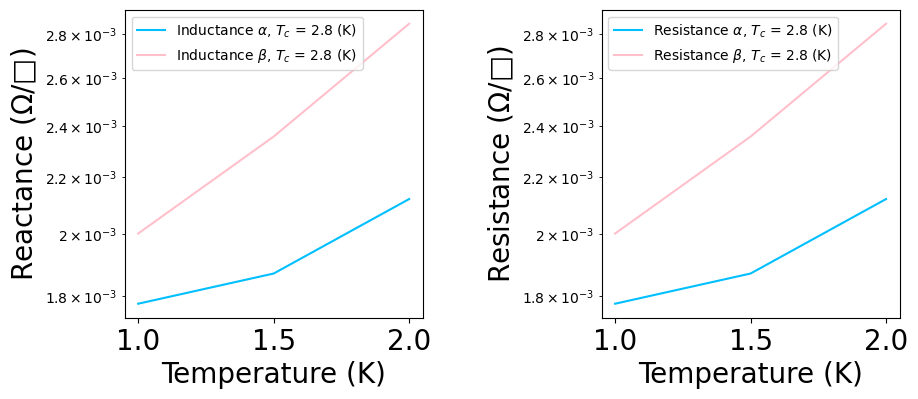

In [8]:
calculate_impedance.single_frequency()
plot_impedance.single_frequency()

## 2.4 Result Saving

In [10]:
# OOP Version

class save_impedance:

    def single_frequency():
        df = pd.DataFrame(
            {
            'T(K)': temp_space,
            'ind_alpha': ind_alpha,
            'res_alpha': res_alpha,
            'ind_beta': ind_beta,
            'res_beta': res_beta
            })
        # 这点需要改因为不知道，要把matched和unmatached区别开
        df.to_excel(save_path_1+"impedance_data__single_f.xlsx")

    def single_frequency_matched():
        df = pd.DataFrame(
            {
            'T(K)': temp_space,
            'ind_alpha': ind_alpha,
            'res_alpha': res_alpha,
            'ind_beta': ind_beta,
            'res_beta': res_beta
            })
        # 这点需要改因为不知道，要把matched和unmatached区别开
        df.to_excel(save_path_1+"impedance_data__single_f_Matched.xlsx")

    def multiple_frequency():
        impedance_list = ['ind_alpha','res_alpha','ind_beta','res_beta']
    
        for i in range(len(impedance_list)): 
            Matrix_name = impedance_list[i]
            Matrix = locals()[Matrix_name]
            Matrix_a = np.insert(Matrix, 0, freq_space, axis=0)
            new_column = np.append(100, temp_space)
            Matrix_b = np.insert(Matrix_a, 0, new_column, axis=1)
            Matrix_c = Matrix_b.astype(str)
            Matrix_c[0,0] = 'T(K) \ f(GHz)'
            df = pd.DataFrame(Matrix_c)
            df.to_excel(save_path_1+Matrix_name+'__multiple_f.xlsx', index=False, header=False)
            

In [11]:
save_impedance.single_frequency()

In [ ]:
save_path_1

# 3 HFSS Simulation File Generation

## 3.1 Template File Initialization

In [12]:
def template_generation():
    # create instance
    project_name = save_path_1+template_aedt_name

    non_graphical = False
    creat_project = Hfss(project=project_name,
                       version=HFSS_version,
                       design=design_name,
                       non_graphical=non_graphical,
                       new_desktop=True
                       #solution_type="Eigenmode"
                       )
    
    print("Project name " + project_name)

    return creat_project, project_name

In [13]:
# whether ther should be a input is a question now, input is the directory
def import_gds():
    
    import_name = 'signal'+str(layer_namber)+'_1'
    
    creat_project.import_gds_3d(gds_file , mapping_layers={layer_namber: (thickness, elevation)}, units='um', import_method=1)
    resonator = creat_project.modeler.get_object_from_name(import_name)
    
    return resonator

In [14]:
def create_layout():

    # Define geometrical unit
    creat_project.modeler.model_units = "um"

    # Device design parameters
    rectangle_01_length = 960
    rectangle_width = 100
    rectangle_011_length = rectangle_01_length - rectangle_width
    
    rectangle_02_length = 760
    rectangle_022_length = rectangle_02_length - rectangle_width
    
    gate_length_01 = 80
    gate_length_02 = 80
    
    meander_width = 10
    meander_gap = 50
    meander_head_long = 130
    meander_head_short = 30
    meander_length = 490
    meander_half = (meander_length - (meander_gap + meander_width))/2
    


    #Outter_Capacitor
    
    global orientation, origin, sizes, origin_0, radius_0, radius_1, origin_2, sizes_2
    orientation = 'XY'
    
    origin = [-0.5*rectangle_01_length, -0.5*rectangle_01_length, 0]
    sizes = [rectangle_01_length, rectangle_01_length]
    name = 'rectangle_01'
    rectangle_01 = creat_project.modeler.create_rectangle(orientation, origin, sizes, name, is_covered=True)
    
    
    origin = [-0.5*rectangle_011_length, -0.5*rectangle_011_length, 0]
    sizes = [rectangle_011_length, rectangle_011_length]
    name = 'rectangle_011'
    rectangle_011 = creat_project.modeler.create_rectangle(orientation, origin, sizes, name, is_covered=True)
    
    
    origin = [0.5*rectangle_011_length, -0.5*gate_length_01, 0]
    sizes = [0.5*rectangle_width, gate_length_01]
    name = 'gate_01'
    gate_01 = creat_project.modeler.create_rectangle(orientation, origin, sizes, name, is_covered=True)
    
    
    blank_list = rectangle_01
    tool_list = [rectangle_011,gate_01]
    rectangle_outer = creat_project.modeler.subtract(blank_list, tool_list, keep_originals=False)
    
    
    # Inner_Capacitor
    
    orientation = 'XY'
    
    origin = [-0.5*rectangle_02_length, -0.5*rectangle_02_length, 0]
    sizes = [rectangle_02_length, rectangle_02_length]
    name = 'rectangle_02'
    rectangle_02 = creat_project.modeler.create_rectangle(orientation, origin, sizes, name, is_covered=True)
    
    origin = [-0.5*rectangle_022_length, -0.5*rectangle_022_length, 0]
    sizes = [rectangle_022_length, rectangle_022_length]
    name = 'rectangle_022'
    rectangle_022 = creat_project.modeler.create_rectangle(orientation, origin, sizes, name, is_covered=True)
    
    origin = [-0.5*rectangle_022_length, -0.5*gate_length_02, 0]
    sizes = [-0.5*rectangle_width, gate_length_02]
    name = 'gate_02'
    gate_02 = creat_project.modeler.create_rectangle(orientation, origin, sizes, name, is_covered=True)
    
    blank_list = rectangle_02
    tool_list = [rectangle_022,gate_02]
    rectangle_inner = creat_project.modeler.subtract(blank_list, tool_list, keep_originals=False)
    
    
    # Meander heads
    
    orientation = 'XY'
    
    origin = [-0.5*rectangle_011_length, -0.5*meander_width, 0]
    sizes = [meander_head_long, meander_width]
    name = 'meander_head_upper'
    meander_head_upper = creat_project.modeler.create_rectangle(orientation, origin, sizes, name, is_covered=True)
    
    origin = [0.5*rectangle_022_length, -0.5*meander_width, 0]
    sizes = [-meander_head_short, meander_width]
    name = 'meander_head_lower'
    meander_head_lower = creat_project.modeler.create_rectangle(orientation, origin, sizes, name, is_covered=True)
    
    
    # Meanders
    for i in range(8):
        orientation = 'XY'
        meander_x = -(3.5*meander_gap + 4*meander_width) + i*(meander_gap + meander_width)
        origin = [meander_x, -0.5*meander_length, 0]
        sizes = [meander_width, meander_length]
        exec('name = "meander_'+str(i)+'"',globals())
        exec('meander_'+str(i)+' = creat_project.modeler.create_rectangle(orientation, origin, sizes, name, is_covered=True)',globals())
    
        
        
    # Meanders_half   
    orientation = 'XY'
    
    origin = [-(4.5*meander_gap + 5*meander_width), -0.5*meander_length, 0]
    sizes = [ meander_width, meander_half]
    name = 'meander_half_upper'
    meander_half_upper = creat_project.modeler.create_rectangle(orientation, origin, sizes, name, is_covered=True)
    
    origin = [(4.5*meander_gap + 5*meander_width), -0.5*meander_length, 0]
    sizes = [ -meander_width, meander_half]
    name = 'meander_half_lower'
    meander_half_lower = creat_project.modeler.create_rectangle(orientation, origin, sizes, name, is_covered=True)
    
    
    
    #meander_corners
    for i in range(5):
        orientation = 'XY'
        circle_x = -4*(meander_gap + meander_width) + i*2*(meander_gap + meander_width)
        origin_0 = [circle_x, -0.5*meander_length, 0]
        radius_0 = 0.5*meander_gap
        global name_0, name_1, name_2
        exec('name_0 = "meander_corner_L_1'+str(i)+'"',globals())
        exec('meander_corner_L_1'+str(i)+' = creat_project.modeler.create_circle(orientation, origin = origin_0, radius = radius_0, num_sides=0, is_covered=True, name = name_0, material=None, non_model=False)',globals())
        radius_1= 0.5*(meander_gap + 2*meander_width)
        exec('name_1 = "meander_corner_L_11'+str(i)+'"',globals())
        exec('meander_corner_L_11'+str(i)+' = creat_project.modeler.create_circle(orientation, origin = origin_0, radius = radius_1, num_sides=0, is_covered=True, name = name_1, material=None, non_model=False)',globals())
        meander_x = -(4.5*meander_gap + 5*meander_width) + i*2*(meander_gap + meander_width)
        origin_2 = [meander_x, -0.5*meander_length, 0]
        sizes_2 = [2*meander_width + meander_gap, 0.5*(2*meander_width + meander_gap)]
        exec('name_2 = "rec_tool_L_'+str(i)+'"',globals())
        exec('rec_tool_L_'+str(i)+' = creat_project.modeler.create_rectangle(orientation, origin = origin_2, sizes = sizes_2, name = name_2, is_covered=True)',globals())
        
        exec('blank_list = meander_corner_L_11'+str(i)+'',globals())
        exec('tool_list = [meander_corner_L_1'+str(i)+',rec_tool_L_'+str(i)+']',globals())
        exec('rec_tool_L0_'+str(i)+' = creat_project.modeler.subtract(blank_list, tool_list, keep_originals=False)',globals())
        
    for i in range(4):
        orientation = 'XY'
        circle_x = -3*(meander_gap + meander_width) + i*2*(meander_gap + meander_width)
        origin_0 = [circle_x, 0.5*meander_length, 0]
        radius_0 = 0.5*meander_gap
        exec('name_0 = "meander_corner_R_1'+str(i)+'"',globals())
        exec('meander_corner_R_1'+str(i)+' = creat_project.modeler.create_circle(orientation, origin = origin_0, radius = radius_0, num_sides=0, is_covered=True, name = name_0, material=None, non_model=False)',globals())
        radius_1= 0.5*(meander_gap + 2*meander_width)
        exec('name_1 = "meander_corner_R_11'+str(i)+'"',globals())
        exec('meander_corner_R_11'+str(i)+' = creat_project.modeler.create_circle(orientation, origin = origin_0, radius = radius_1, num_sides=0, is_covered=True, name = name_1, material=None, non_model=False)',globals())
        meander_x = -(3.5*meander_gap + 4*meander_width) + i*2*(meander_gap + meander_width)
        origin_2 = [meander_x, 0.5*meander_length]
        sizes_2 = [2*meander_width + meander_gap, -0.5*(2*meander_width + meander_gap)]
        exec('name_2 = "rec_tool_R_'+str(i)+'"',globals())
        exec('rec_tool_R_'+str(i)+' = creat_project.modeler.create_rectangle(orientation, origin = origin_2, sizes = sizes_2, name = name_2, is_covered=True)',globals())
        
        exec('blank_list = meander_corner_R_11'+str(i)+'',globals())
        exec('tool_list = [meander_corner_R_1'+str(i)+',rec_tool_R_'+str(i)+']',globals())
        exec('rec_tool_R0_'+str(i)+' = creat_project.modeler.subtract(blank_list, tool_list, keep_originals=False)',globals())
        
    
        
        
    #meander_corners_half
    orientation = 'XY'
    
    position = [-5*(meander_gap + meander_width), -0.5*(meander_gap + meander_width), 0]
    radius1= 0.5*(meander_gap + 2*meander_width)
    name_1 = "meander_corner_upper_1"
    meander_corner_upper_1 = creat_project.modeler.create_circle(orientation, origin = position, radius = radius1, num_sides=0, is_covered=True, name = name_1, material=None, non_model=False)
    radius11= 0.5*meander_gap
    name_11 = "meander_corner_upper_11"
    meander_corner_upper_11 = creat_project.modeler.create_circle(orientation, origin = position, radius = radius11, num_sides=0, is_covered=True, name = name_11, material=None, non_model=False)
    
    position = [-1*(5.5*meander_gap + 6*meander_width), -(1.5*meander_width + meander_gap), 0]
    dimension_list = [(2*meander_width + meander_gap), 0.5*(2*meander_width + meander_gap)]
    name_0 = 'meander_corner_upper_111'
    meander_corner_upper_111 = creat_project.modeler.create_rectangle(orientation, origin = position, sizes = dimension_list, name = name_0, is_covered=True)
    dimension_list = [0.5*(2*meander_width + meander_gap), (2*meander_width + meander_gap)]
    name_0 = 'meander_corner_upper_1111'
    meander_corner_upper_1111 = creat_project.modeler.create_rectangle(orientation, origin = position, sizes = dimension_list, name = name_0, is_covered=True)
    
    blank_list = meander_corner_upper_1
    tool_list =[meander_corner_upper_11,meander_corner_upper_111,meander_corner_upper_1111]
    meander_corner_upper_0 = creat_project.modeler.subtract(blank_list, tool_list, keep_originals=False)
    
    
    
    orientation = 'XY'
    
    position = [5*(meander_gap + meander_width), -0.5*(meander_gap + meander_width), 0]
    radius1= 0.5*(meander_gap + 2*meander_width)
    name_1 = "meander_corner_lower_1"
    meander_corner_lower_1 = creat_project.modeler.create_circle(orientation, origin = position, radius = radius1, num_sides=0, is_covered=True, name = name_1, material=None, non_model=False)
    radius11= 0.5*meander_gap
    name_11 = "meander_corner_lower_11"
    meander_corner_lower_11 = creat_project.modeler.create_circle(orientation, origin = position, radius = radius11, num_sides=0, is_covered=True, name = name_11, material=None, non_model=False)
    
    position = [1*(5.5*meander_gap + 6*meander_width), -(1.5*meander_width + meander_gap), 0]
    dimension_list = [-(2*meander_width + meander_gap), 0.5*(2*meander_width + meander_gap)]
    name_0 = 'meander_corner_lower_111'
    meander_corner_lower_111 = creat_project.modeler.create_rectangle(orientation, origin = position, sizes = dimension_list, name = name_0, is_covered=True)
    dimension_list = [-0.5*(2*meander_width + meander_gap), (2*meander_width + meander_gap)]
    name_0 = 'meander_corner_lower_1111'
    meander_corner_lower_1111 = creat_project.modeler.create_rectangle(orientation, origin = position, sizes = dimension_list, name = name_0, is_covered=True)
    
    blank_list = meander_corner_lower_1
    tool_list =[meander_corner_lower_11,meander_corner_lower_111,meander_corner_lower_1111]
    meander_corner_lower_0 = creat_project.modeler.subtract(blank_list, tool_list, keep_originals=False)
    
    
    
    
    #Unite
    theList = [rectangle_01, rectangle_02, meander_head_upper, meander_head_lower, meander_corner_upper_1, meander_corner_lower_1, \
              meander_half_upper, meander_half_lower, meander_corner_L_110, meander_corner_L_111, meander_corner_L_112, meander_corner_L_113, \
              meander_corner_L_114, meander_corner_R_110, meander_corner_R_111, meander_corner_R_112, meander_corner_R_113, meander_0, \
              meander_1, meander_2, meander_3, meander_4, meander_5, meander_6, meander_7]
    creat_project.modeler.unite(theList, purge=False)
    resonator = rectangle_01
    
    # purge 
    creat_project.modeler.purge_history(resonator)

    return resonator

In [ ]:
# import pdb

In [15]:
class Grid():
    def __init__(self,name,row_col_index,position,length):
        self.name = name
        self.row_col_index = row_col_index
        self.position = position
        self.length = length
        
def function():

    # 3.03 Secondary grids generation
    
    # Generating a virtual chessboard
    # In the case that the secondary phase concentration is higher than the length ratio between the grid and the chessboard, multiple grids in each
    # row in the chessboard will be selected as the secondary phase. In the case that the secondary phase concentration is lower than the length ratio, 
    # one grid in each row will be selected, and part of it will be set to be the secondary phase according to the defined concentration
    # The grid selection is random, a specific secondary phase distribution requires new codes
    # 'exec' command requires globle or pre-defined variables when it is called in a function

    # class Grid():
    #     def __init__(self,name,row_col_index,position,length):
    #         self.name = name
    #         self.row_col_index = row_col_index
    #         self.position = position
    #         self.length = length

    
    creat_project.modeler.model_units = "um"
    
    variables = {}  
    global name, order, row_col_index, the_position, the_length, temp_name
    global orientation, position, dimension_list, name_0
    
        
    board_length = chess_board_length
    grid_length = mesh_grid_dimension
    mesh_board_ratio = grid_length/board_length
        
    if beta_concentration <= mesh_board_ratio:
            
        len_ratio = np.sqrt(beta_concentration/(grid_length/board_length))
        row_number = int(board_length/grid_length)
        colomn_number = int(board_length/grid_length)
        for i in range(row_number):
            exec('row_'+str(i)+'= []', variables, globals())
            for j in range(colomn_number):     
                name = 'grid_row_'+str(i)+'_col_'+str(j)
                order = str(i*row_number+j)
                row_col_index = [i,j]
                the_position = [i*grid_length - 0.5*board_length, j*grid_length - 0.5*board_length, 0]
                the_length = [grid_length*len_ratio, grid_length*len_ratio]
                temp_name = 'grid_row_'+str(i)+'_col_'+str(j)
                exec('row_'+str(i)+'.append(temp_name)', variables, globals())
                exec('grid_row_'+str(i)+'_col_'+str(j)+'= Grid(name,row_col_index,the_position,the_length)', variables, globals())
                    
                    
                    
        # Selecting beta grids and put them into HFSS
        percentage = beta_concentration
        # # high beta concentration
        # per_number = int(percentage*row_number)
        # low  beta concentration
        per_number = int(1)
        column_list = np.linspace(1, colomn_number,colomn_number)
        column_list = list(map(int, column_list-1))
        
        beta_phase = []
        
        for i in track(range(row_number), description="Creating grids......"):
            random_list = random.sample(column_list,per_number)
            # beta-phase
            for k in range(per_number):
                b = random_list[k] 
                exec('slected_grid = grid_row_'+str(i)+'_col_'+str(b)+'', variables, globals())
                position = slected_grid.position
                # dimension_list = slected_grid.length*len_ratio 
                dimension_list = [n * len_ratio for n in slected_grid.length]
                name_0 = str(i*per_number + k)
                orientation = 'XY'
                exec('HFSS_grid_row_'+str(i)+'_col_'+str(b)+' = '+'creat_project.modeler.create_rectangle(orientation, origin = position, sizes = dimension_list, name=name_0, is_covered=True)', variables, globals())
                # slected_grid.color = [255, 0, 0]
                exec('name_1 = "HFSS_grid_row_'+str(i)+'_col_'+str(b)+'"', variables, globals())              
                beta_phase.append(eval(name_1))
    
    
    else:
        row_number = int(board_length/grid_length)
        colomn_number = int(board_length/grid_length)
        for i in range(row_number):
            exec('row_'+str(i)+'= []', variables, globals())
            for j in range(colomn_number):
                name = 'grid_row_'+str(i)+'_col_'+str(j)
                order = str(i*row_number+j)
                row_col_index = [i,j]
                the_position = [i*grid_length - 0.5*board_length, j*grid_length - 0.5*board_length, 0]
                the_length = [grid_length, grid_length]
        
                temp_name = 'grid_row_'+str(i)+'_col_'+str(j)
                exec('row_'+str(i)+'.append(temp_name)', variables, globals())
                exec('grid_row_'+str(i)+'_col_'+str(j)+'= Grid(name,row_col_index,the_position,the_length)', variables, globals())
        
        
                    
                    
                    
        # Selecting beta grids and put them into HFSS
        percentage = beta_concentration
        per_number = int(percentage*row_number)
        column_list = np.linspace(1, colomn_number,colomn_number)
        column_list = list(map(int, column_list-1))
        
        beta_phase = []
        
        for i in track(range(row_number), description="Creating grids......"):
            random_list = random.sample(column_list,per_number)
            # beta-phase
            for k in range(per_number):
                b = random_list[k] 
                exec('slected_grid = grid_row_'+str(i)+'_col_'+str(b)+'', variables, globals())
                position = slected_grid.position
                dimension_list = slected_grid.length                                                     
                name_0 = str(i*per_number + k)
                orientation = 'XY'
                exec('HFSS_grid_row_'+str(i)+'_col_'+str(b)+' = '+'creat_project.modeler.create_rectangle(orientation, origin = position, sizes = dimension_list, name=name_0, is_covered=True)', variables, globals())
                # slected_grid.color = [255, 0, 0]
                exec('name_1 = "HFSS_grid_row_'+str(i)+'_col_'+str(b)+'"', variables, globals())
                beta_phase.append(eval(name_1))




    # 3.04 Secondary grids segmentation
    
    # Segmentation operation between the device object and the chessboard object
    # The second resonator needed for intersection
    vector_0 = [100,0,0]
    vector_re0 = [-100,0,0]
    # resonator has been defined before
    resonator_d = creat_project.modeler.duplicate_along_line(resonator,clones=2, vector = vector_0, attach=False, is_3d_comp=False, duplicate_assignment=True)
    resonator_d0 = creat_project.modeler.get_object_from_name(resonator_d[1][0])
    resonator_d0.move(vector_re0)
    
    
    # Subtraction to create Alpha phase
    b_length = len(beta_phase)
    for i in track(range(b_length), description="Subtracting beta grids......"):
        grid_name = str(i)
        the_grid = creat_project.modeler.get_object_from_name(grid_name)
        
        blank_list = resonator
        tool_list = the_grid
        creat_project.modeler.subtract(blank_list, tool_list, keep_originals=True)
    
    
    # Intersection to creat Beta phase
    for i in track(range(b_length), description="Intersecting beta grids......"):
        grid_name = str(i)
        the_grid = creat_project.modeler.get_object_from_name(grid_name)
        
        theList = [the_grid, resonator_d0]
        intersection_result = creat_project.modeler.intersect(theList, keep_originals=True)
        
        if type(intersection_result) == str:
                print('intersection works')
        else:
                beta_phase.remove(the_grid)
                creat_project.modeler.delete(the_grid)
    
    # delete resonator_d0
    creat_project.modeler.delete(resonator_d0)




    # 3.05 Boundary generation
    
    # Generate boundary conditions for both primary phase and secondary phase
    # Unite and rename to phases
    # global alpha_area, alpha_id, alpha_phase_grids, beta_phase_grids
    
    alpha_phase_grids = resonator
    beta_phase_grids = creat_project.modeler.unite(beta_phase)
    creat_project.modeler.purge_history(beta_phase_grids)
    
    if beta_phase_grids == False:
        print(colored('Failed to create beta phase! Please modify the beta phase parameters!','red'))
    
    else:
        # set variable
        beta_res = creat_project.variable_manager.set_variable("beta_res", expression="10", overwrite = True)
        beta_ind = creat_project.variable_manager.set_variable("beta_ind", expression="20", overwrite = True)
        alpha_res = creat_project.variable_manager.set_variable("alpha_res", expression="1", overwrite = True)
        alpha_ind = creat_project.variable_manager.set_variable("alpha_ind", expression="2", overwrite = True)
        # set impedance boundary
        beta_boundary = creat_project.assign_impedance_to_sheet(beta_phase_grids, "beta_boundary",  'beta_res', 'beta_ind')
        alpha_boundary = creat_project.assign_impedance_to_sheet(alpha_phase_grids.name, "alpha_boundary",  'alpha_res', 'alpha_ind')
        # here name of the object is required




    # 3.06 Concentration checking

    # There is a possibility that the resulting secondary phase concentration is very far from the required value due to the uncertainty produced by 
    # the segmentation process. Reducing the dimension of the grid can reduce the deviation, but will certainly increase the time in generating the 
    # template and computational resource for simulation. 
    # If the concentration deviation is too large, the mark concentration_check will be set to 1

    alpha_id = creat_project.modeler.get_object_faces(alpha_phase_grids.id)
    alpha_area = 0
    for i in range(len(alpha_id)):
        alpha_area_i = creat_project.modeler.get_face_area(alpha_id[i])
        alpha_area = alpha_area + alpha_area_i
        
    # beta_id = creat_project.modeler.get_object_faces(beta_phase_grids.id)
    
    beta_name = beta_phase_grids
    beta_ob = creat_project.modeler.get_object_from_name(beta_name)
    beta_id = creat_project.modeler.get_object_faces(beta_ob.id)
    beta_area = 0
    for i in range(len(beta_id)):
        beta_area_i = creat_project.modeler.get_face_area(beta_id[i])
        beta_area = beta_area + beta_area_i
        
        
    real_beta_con = beta_area/alpha_area
    ratio = real_beta_con/beta_concentration
    
        
    col = ['alpha_area', 'beta_area','real_beta_con','target_beta_con','Ratio']
    data = [[str(alpha_area),str(beta_area),str(real_beta_con),str(beta_concentration),str(ratio)]]
    mat = np.vstack((col,data))
    data_frame = pd.DataFrame(data,columns=col)
    data_frame.to_excel(save_path_1+template_aedt_name+"area_ratio.xlsx") 
    
    # output ratio
    print('Beta concentration real/target ratio is '+str(ratio))
    check_flag = 0

    upper_limit = 1 + concentration_deviation_condition
    lower_limit = 1 - concentration_deviation_condition
    if ratio >= upper_limit or ratio <= lower_limit:
        print(colored('Beta phase concentration is off the target value, reduce the grids dimension or relax the concentration condition', 'red'))
        check_flag = 1
        time.sleep(3)
        creat_project.release_desktop()
        os.remove(project_name+'.aedt')
    else:
        print('Error of beta phase area is less than 10%, continue')



        # 3.07 Simulation environment creation 
    
        # Create substrate and air box. Here air box can be replaced by a waveguide, which can be imported or created 
        creat_project.modeler.model_units = "um"
        
        # vac_length = 10000
        # vac_height = 10000
        origin = [-0.5*vac_length,-0.5*vac_length,-0.5*vac_height]
        dimensions = [vac_length,vac_length,vac_height]
        vacuum_box = creat_project.modeler.create_box(origin, dimensions, name="vacuum_box", material="vacuum")
        
        ids = [i.id for i in creat_project.modeler["vacuum_box"].faces]
        PE = creat_project.assign_perfecte_to_sheets(ids)
        
        
        #creat substrate_tool
        
        # sub_length = 7000
        # sub_height = 330
        origin = [-0.5*sub_length,-0.5*sub_length,-sub_height]
        dimensions = [sub_length,sub_length,sub_height]
        substrate_tool = creat_project.modeler.create_box(origin, dimensions, name="substrate_tool", material="vacuum")
        
        vacuum_box_0 = creat_project.modeler.subtract(vacuum_box, substrate_tool, keep_originals=False)
        
        #creat substrate
        origin = [-0.5*sub_length,-0.5*sub_length,-sub_height]
        dimensions = [sub_length,sub_length,sub_height]
        substrate = creat_project.modeler.create_box(origin, dimensions, name="substrate", material="sapphire")




        # 3.08 FEM Meshing
    
        # Mostly meshing is necessary to generate some reasonable results.
        # creat mesh_box for resonator
        if resonator_mesh_box == 1:
            mesh_box_length = 2000
            origin = [-0.50*mesh_box_length,-0.50*mesh_box_length,-0.5*mesh_box_length]
            dimensions = [mesh_box_length,mesh_box_length,mesh_box_length]
            mesh_box = creat_project.modeler.create_box(origin, dimensions, name="mesh_box", material=None)
            mesh_box.model = False
        
            #mesh box
            box_max_mesh_len = 100
            mesh_box = creat_project.mesh.assign_length_mesh(mesh_box, inside_selection=True, maximum_length=box_max_mesh_len, maximum_elements=None, name="mesh_box")
        else:
            pass
            
            
        #mesh substrate
        substrat_max_mesh_len = 10
        mesh_substrat = creat_project.mesh.assign_length_mesh(substrate, inside_selection=True, maximum_length=substrat_max_mesh_len, maximum_elements=None, name="mesh_substrat")
            
    
        
        #mesh resonator
        mesh_list = [beta_phase_grids,alpha_phase_grids]
        alpha_max_mesh_len = 10
        beta_max_mesh_len = 10
        creat_project.mesh.assign_length_mesh(alpha_phase_grids, inside_selection=True, maximum_length=alpha_max_mesh_len, maximum_elements=None, name="alpha_phase")
        creat_project.mesh.assign_length_mesh(beta_phase_grids, inside_selection=True, maximum_length=beta_max_mesh_len, maximum_elements=None, name="beta_phase")
    
    
    
    
        # 3.09 HFSS simulation setting
    
        # As mentioned before, 'Eigenmode' is defined here
    
        creat_project.solution_type = "Eigenmode" 
        
        creat_project.create_setup(
            name=setup_name,  
            MinimumFrequency="2GHz", 
            NumModes = 1,
            MaximumPasses=20,
            MaxDeltaFreq=1,
            PercentRefinement=20,
            MinimumConvergedPasses=2,
            MinimumPasses=2)
    



        # 3.10 Template file finalization
        
        # Validation is very necessary, especially when generating a dense chessboard with a large number of grids, because the segmentation operation in HFSS
        # can easily produce errors
        
        # Validate design
        Validation = creat_project.validate_full_design()
        print(Validation)
        if Validation[1] == False:
            print(colored('Validation failed, reduce the grids dimension may solve the problem', 'red'))
            creat_project.release_desktop()
            os.remove(project_name+'.aedt')
            check_flag = 1
        else:
            creat_project.save_project()
            creat_project.release_desktop()
            print(colored('Validation succeeded, template file is saved', 'red'))
    
        return check_flag

In [20]:
creat_project, project_name = template_generation()

PyAEDT INFO: Python version 3.11.10 | packaged by Anaconda, Inc. | (main, Oct  3 2024, 07:22:26) [MSC v.1929 64 bit (AMD64)]
PyAEDT INFO: PyAEDT version 0.11.0.
PyAEDT INFO: Initializing new Desktop session.
PyAEDT INFO: Log on console is enabled.
PyAEDT INFO: Log on file C:\Users\65751\AppData\Local\Temp\pyaedt_65751_59560a44-f7a6-42d4-923c-68c9ba9d8ec6.log is enabled.
PyAEDT INFO: Log on AEDT is enabled.
PyAEDT INFO: Debug logger is disabled. PyAEDT methods will not be logged.
PyAEDT INFO: Launching PyAEDT with gRPC plugin.
PyAEDT INFO: New AEDT session is starting on gRPC port 58765
PyAEDT INFO: AEDT installation Path C:\Program Files\AnsysEM\v232\Win64
PyAEDT INFO: Ansoft.ElectronicsDesktop.2023.2 version started with process ID 30396.
PyAEDT INFO: Project template_file has been created.
PyAEDT INFO: Added design 'Design01' of type HFSS.
PyAEDT INFO: Aedt Objects correctly read
Project name C:\Users\65751\Documents\HFSS_files\2025_06_26\5.0per_Beta\aBCS_1.8_bBCS_0.8\template_file


In [21]:
#resonator = import_gds()
resonator = create_layout()

PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Materials class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Parsing design objects. This operation can take time
PyAEDT INFO: Parsing C:/Users/65751/Documents/HFSS_files/2025_06_26/5.0per_Beta/aBCS_1.8_bBCS_0.8/template_file.aedt.
PyAEDT INFO: File C:/Users/65751/Documents/HFSS_files/2025_06_26/5.0per_Beta/aBCS_1.8_bBCS_0.8/template_file.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: aedt file load time 0.03167915344238281
PyAEDT INFO: 3D Modeler objects parsed. Elapsed time: 0m 0sec
PyAEDT INFO: Union of 25 objects has been executed.


In [22]:
# mesh_grid_dimension = 100                                    # Unit:um
# chess_board_length = 4000 
# concentration_deviation_condition = 0.5

In [23]:
function()

Output()

Output()

Output()

PyAEDT INFO: Intersection Succeeded


intersection works

...

intersection works

PyAEDT INFO: Intersection Succeeded


intersection works

PyAEDT INFO: Deleted 1 Objects: rectangle_01_1.
PyAEDT INFO: Union of 10 objects has been executed.
PyAEDT INFO: Boundary Impedance beta_boundary has been correctly created.
PyAEDT INFO: Boundary Impedance alpha_boundary has been correctly created.
Beta concentration real/target ratio is 0.6119327173427723
Error of beta phase area is less than 10%, continue
PyAEDT INFO: Boundary Perfect E PerfE_U6ZTM7 has been correctly created.
PyAEDT INFO: Mesh class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Mesh class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Design validation checks.
PyAEDT INFO: Eigen model is detected. No excitatons are defined.
(['Desktop messages:', '[warning] Purge History: The following parts will also be purged: rectangle_01 (08:47:10 AM  Jun 26, 2025)', 'Design validation check PASSED.', 'Design validation messages:', '** End of design validation messages. **', 'Excitations check:', 'Eigen model is detected. No excitatons are defined.', 'Analys

0

## 3.11 .aedt Files Batch Generation

In [24]:
def aedt_batch_generation():
    # Copy the template file, rename the copied file, replace the impedance boundary value


    # before open the desktop, release it again
    Hfss.release_desktop
    time.sleep(sleep_time)
    
    file_name = str(beta_concentration) +'BetaCon_'+str(alpha_Tc)+'K_'+str(beta_Tc)+'K_'
    original_name = project_name + '.aedt'
    
    # rename impedance variables
    alpha_res_val = res_alpha
    alpha_ind_val = ind_alpha
    beta_res_val = res_beta
    beta_ind_val = ind_beta

    # create a global variable is essential for calling Hfss in a function and out of the loop
    global creat_copy_project
    for i in track(range(len(temp_space)), description="Setting impedance..."):
        #copy file
        T_str = format(temp_space[i], '0.3f')  
        T_str = T_str[0:4]
        file_format = '_K.aedt'
        copy_name = save_path_1+file_name+T_str+file_format
        shutil.copyfile(original_name, copy_name)
        
        # optional
        # wait for the copy process
        time.sleep(sleep_time) 
        
        #open the copied file
        creat_copy_project = Hfss(project=copy_name)



        if single_frequency == 1: 
            # creat sweep and sync the res and ind
            parametric_beta_res = creat_copy_project.parametrics.add(variable = 'beta_res', start_point = beta_res_val[i], variation_type = 'SingleValue')
            parametric_beta_res.add_variation(sweep_variable = 'beta_ind', start_point = beta_ind_val[i], variation_type = 'SingleValue')
            parametric_beta_res.add_variation(sweep_variable = 'alpha_res', start_point = alpha_res_val[i], variation_type = 'SingleValue')
            parametric_beta_res.add_variation(sweep_variable = 'alpha_ind', start_point = alpha_ind_val[i], variation_type = 'SingleValue')
    
        else:
            # creat sweep and sync the res and ind
            parametric_beta_res = creat_copy_project.parametrics.add(sweep_var = 'beta_res', start_point = beta_res_val[i,0], variation_type = 'SingleValue')
            parametric_beta_res.add_variation(sweep_var = 'beta_ind', start_point = beta_ind_val[i,0], variation_type = 'SingleValue')
            parametric_beta_res.add_variation(sweep_var = 'alpha_res', start_point = alpha_res_val[i,0], variation_type = 'SingleValue')
            parametric_beta_res.add_variation(sweep_var = 'alpha_ind', start_point = alpha_ind_val[i,0], variation_type = 'SingleValue')
            
            time.sleep(1)
            for j in range(step_f-1):
                parametric_beta_res.add_variation(sweep_var = 'beta_res', start_point = beta_res_val[i,j+1], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'beta_ind', start_point = beta_ind_val[i,j+1], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'alpha_res', start_point = alpha_res_val[i,j+1], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'alpha_ind', start_point = alpha_ind_val[i,j+1], variation_type = 'SingleValue')
    
        # sync the variables
        variables = ['beta_res', 'beta_ind','alpha_res','alpha_ind']
        parametric_beta_res.sync_variables(variables)
    
        # close file
        creat_copy_project.save_project()
        # pyaedt.desktop.release_desktop()
        creat_copy_project.release_desktop(close_projects=True, close_desktop=True)
    
        # optional
        # the new file open should be later than last file close
        time.sleep(sleep_time) 
        

In [25]:
class aedt_batch_generation:

    
    def different_Tc():

        global creat_copy_project, sleep_time, project_name,file_name, original_name, alpha_res_val, alpha_ind_val, beta_res_val, beta_ind_val
        global T_str, file_format, copy_name, parametric_beta_res

        sleep_time = 30
        
        project_name = save_path_1+template_aedt_name
        
        #file_name = str(beta_concentration) +'BetaCon_'+str(alpha_Tc)+'K_'+str(beta_Tc)+'K_'
        #file_name = str(beta_concentration) +'BetaCon_'+'aTc'+str(alpha_Tc)+'_bTc'+str(beta_Tc)+'_'
        file_name = str(beta_concentration) + 'BetaCon_' + 'aTc' + str(alpha_Tc) + '_bTc' + str(beta_Tc) + '_'
        original_name = project_name + '.aedt'
        
        # rename impedance variables
        alpha_res_val = res_alpha
        alpha_ind_val = ind_alpha
        beta_res_val = res_beta
        beta_ind_val = ind_beta
        
        # create a global variable is essential for calling Hfss in a function and out of the loop
        
        for i in track(range(len(temp_space)), description="Setting impedance..."):
            #copy file
            T_str = format(temp_space[i], '0.3f')  
            T_str = T_str[0:4]
            file_format = 'K.aedt'
            copy_name = save_path_1+file_name+T_str+file_format
            shutil.copyfile(original_name, copy_name)
            
            # optional
            # wait for the copy process
            time.sleep(2) 
            
            #open the copied file
            creat_copy_project = Hfss(project=copy_name)
        
            time.sleep(20) 
        
            if single_frequency == 1: 
                # creat sweep and sync the res and ind
                parametric_beta_res = creat_copy_project.parametrics.add(variable = 'beta_res', start_point = beta_res_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'beta_ind', start_point = beta_ind_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'alpha_res', start_point = alpha_res_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'alpha_ind', start_point = alpha_ind_val[i], variation_type = 'SingleValue')
        
            else:
                # creat sweep and sync the res and ind
                parametric_beta_res = creat_copy_project.parametrics.add(sweep_var = 'beta_res', start_point = beta_res_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'beta_ind', start_point = beta_ind_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'alpha_res', start_point = alpha_res_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'alpha_ind', start_point = alpha_ind_val[i,0], variation_type = 'SingleValue')
                
                time.sleep(1)
                for j in range(step_f-1):
                    parametric_beta_res.add_variation(sweep_var = 'beta_res', start_point = beta_res_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'beta_ind', start_point = beta_ind_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'alpha_res', start_point = alpha_res_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'alpha_ind', start_point = alpha_ind_val[i,j+1], variation_type = 'SingleValue')
        
            # sync the variables
            variables = ['beta_res', 'beta_ind','alpha_res','alpha_ind']
            parametric_beta_res.sync_variables(variables)
            
            time.sleep(2)
            
            # close file
            creat_copy_project.save_project()
            # pyaedt.desktop.release_desktop()
            creat_copy_project.release_desktop(close_projects=True, close_desktop=True)
        
            # optional
            # the new file open should be later than last file close
            time.sleep(5) 

    
    
    def different_BCS_ratio():

        global creat_copy_project, sleep_time, project_name,file_name, original_name, alpha_res_val, alpha_ind_val, beta_res_val, beta_ind_val
        global T_str, file_format, copy_name, parametric_beta_res

        sleep_time = 30
        
        project_name = save_path_1+template_aedt_name
        
        #file_name = str(beta_concentration) +'BetaCon_'+str(alpha_Tc)+'K_'+str(beta_Tc)+'K_'
        file_name = str(beta_concentration) +'BetaCon_'+'aBCS'+str(alpha_BCS_Ratio)+'_bBCS'+str(beta_BCS_Ratio)+'_'
        original_name = project_name + '.aedt'
        
        # rename impedance variables
        alpha_res_val = res_alpha
        alpha_ind_val = ind_alpha
        beta_res_val = res_beta
        beta_ind_val = ind_beta
        
        # create a global variable is essential for calling Hfss in a function and out of the loop
        
        for i in track(range(len(temp_space)), description="Setting impedance..."):
            #copy file
            T_str = format(temp_space[i], '0.3f')  
            T_str = T_str[0:4]
            file_format = 'K.aedt'
            copy_name = save_path_1+file_name+T_str+file_format
            shutil.copyfile(original_name, copy_name)
            
            # optional
            # wait for the copy process
            time.sleep(2) 
            
            #open the copied file
            creat_copy_project = Hfss(project=copy_name)
        
            time.sleep(20) 
        
            if single_frequency == 1: 
                # creat sweep and sync the res and ind
                parametric_beta_res = creat_copy_project.parametrics.add(variable = 'beta_res', start_point = beta_res_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'beta_ind', start_point = beta_ind_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'alpha_res', start_point = alpha_res_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'alpha_ind', start_point = alpha_ind_val[i], variation_type = 'SingleValue')
        
            else:
                # creat sweep and sync the res and ind
                parametric_beta_res = creat_copy_project.parametrics.add(sweep_var = 'beta_res', start_point = beta_res_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'beta_ind', start_point = beta_ind_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'alpha_res', start_point = alpha_res_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'alpha_ind', start_point = alpha_ind_val[i,0], variation_type = 'SingleValue')
                
                time.sleep(1)
                for j in range(step_f-1):
                    parametric_beta_res.add_variation(sweep_var = 'beta_res', start_point = beta_res_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'beta_ind', start_point = beta_ind_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'alpha_res', start_point = alpha_res_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'alpha_ind', start_point = alpha_ind_val[i,j+1], variation_type = 'SingleValue')
        
            # sync the variables
            variables = ['beta_res', 'beta_ind','alpha_res','alpha_ind']
            parametric_beta_res.sync_variables(variables)
            
            time.sleep(2)
            
            # close file
            creat_copy_project.save_project()
            # pyaedt.desktop.release_desktop()
            creat_copy_project.release_desktop(close_projects=True, close_desktop=True)
        
            # optional
            # the new file open should be later than last file close
            time.sleep(5) 


    

    def different_Coherence():

        global creat_copy_project, sleep_time, project_name,file_name, original_name, alpha_res_val, alpha_ind_val, beta_res_val, beta_ind_val
        global T_str, file_format, copy_name, parametric_beta_res

        sleep_time = 30
        
        project_name = save_path_1+template_aedt_name
        
        #file_name = str(beta_concentration) +'BetaCon_'+str(alpha_Tc)+'K_'+str(beta_Tc)+'K_'
        #file_name = str(beta_concentration) +'BetaCon_'+'aTc'+str(alpha_Tc)+'_bTc'+str(beta_Tc)+'_'
        file_name = str(beta_concentration) + 'BetaCon_' + 'aCoherence' + str(alpha_Coherence) + '_bCoherence' + str(beta_Coherence) + '_'
        original_name = project_name + '.aedt'
        
        # rename impedance variables
        alpha_res_val = res_alpha
        alpha_ind_val = ind_alpha
        beta_res_val = res_beta
        beta_ind_val = ind_beta
        
        # create a global variable is essential for calling Hfss in a function and out of the loop
        
        for i in track(range(len(temp_space)), description="Setting impedance..."):
            #copy file
            T_str = format(temp_space[i], '0.3f')  
            T_str = T_str[0:4]
            file_format = 'K.aedt'
            copy_name = save_path_1+file_name+T_str+file_format
            shutil.copyfile(original_name, copy_name)
            
            # optional
            # wait for the copy process
            time.sleep(2) 
            
            #open the copied file
            creat_copy_project = Hfss(project=copy_name)
        
            time.sleep(20) 
        
            if single_frequency == 1: 
                # creat sweep and sync the res and ind
                parametric_beta_res = creat_copy_project.parametrics.add(variable = 'beta_res', start_point = beta_res_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'beta_ind', start_point = beta_ind_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'alpha_res', start_point = alpha_res_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'alpha_ind', start_point = alpha_ind_val[i], variation_type = 'SingleValue')
        
            else:
                # creat sweep and sync the res and ind
                parametric_beta_res = creat_copy_project.parametrics.add(sweep_var = 'beta_res', start_point = beta_res_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'beta_ind', start_point = beta_ind_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'alpha_res', start_point = alpha_res_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'alpha_ind', start_point = alpha_ind_val[i,0], variation_type = 'SingleValue')
                
                time.sleep(1)
                for j in range(step_f-1):
                    parametric_beta_res.add_variation(sweep_var = 'beta_res', start_point = beta_res_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'beta_ind', start_point = beta_ind_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'alpha_res', start_point = alpha_res_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'alpha_ind', start_point = alpha_ind_val[i,j+1], variation_type = 'SingleValue')
        
            # sync the variables
            variables = ['beta_res', 'beta_ind','alpha_res','alpha_ind']
            parametric_beta_res.sync_variables(variables)
            
            time.sleep(2)
            
            # close file
            creat_copy_project.save_project()
            # pyaedt.desktop.release_desktop()
            creat_copy_project.release_desktop(close_projects=True, close_desktop=True)
        
            # optional
            # the new file open should be later than last file close
            time.sleep(5) 



    def different_London():

        global creat_copy_project, sleep_time, project_name,file_name, original_name, alpha_res_val, alpha_ind_val, beta_res_val, beta_ind_val
        global T_str, file_format, copy_name, parametric_beta_res

        sleep_time = 30
        
        project_name = save_path_1+template_aedt_name
        
        #file_name = str(beta_concentration) +'BetaCon_'+str(alpha_Tc)+'K_'+str(beta_Tc)+'K_'
        #file_name = str(beta_concentration) +'BetaCon_'+'aTc'+str(alpha_Tc)+'_bTc'+str(beta_Tc)+'_'
        file_name = str(beta_concentration) + 'BetaCon_' + 'aLondon' + str(alpha_London) + '_bLondon' + str(beta_London) + '_'
        original_name = project_name + '.aedt'
        
        # rename impedance variables
        alpha_res_val = res_alpha
        alpha_ind_val = ind_alpha
        beta_res_val = res_beta
        beta_ind_val = ind_beta
        
        # create a global variable is essential for calling Hfss in a function and out of the loop
        
        for i in track(range(len(temp_space)), description="Setting impedance..."):
            #copy file
            T_str = format(temp_space[i], '0.3f')  
            T_str = T_str[0:4]
            file_format = 'K.aedt'
            copy_name = save_path_1+file_name+T_str+file_format
            shutil.copyfile(original_name, copy_name)
            
            # optional
            # wait for the copy process
            time.sleep(2) 
            
            #open the copied file
            creat_copy_project = Hfss(project=copy_name)
        
            time.sleep(20) 
        
            if single_frequency == 1: 
                # creat sweep and sync the res and ind
                parametric_beta_res = creat_copy_project.parametrics.add(variable = 'beta_res', start_point = beta_res_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'beta_ind', start_point = beta_ind_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'alpha_res', start_point = alpha_res_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'alpha_ind', start_point = alpha_ind_val[i], variation_type = 'SingleValue')
        
            else:
                # creat sweep and sync the res and ind
                parametric_beta_res = creat_copy_project.parametrics.add(sweep_var = 'beta_res', start_point = beta_res_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'beta_ind', start_point = beta_ind_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'alpha_res', start_point = alpha_res_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'alpha_ind', start_point = alpha_ind_val[i,0], variation_type = 'SingleValue')
                
                time.sleep(1)
                for j in range(step_f-1):
                    parametric_beta_res.add_variation(sweep_var = 'beta_res', start_point = beta_res_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'beta_ind', start_point = beta_ind_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'alpha_res', start_point = alpha_res_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'alpha_ind', start_point = alpha_ind_val[i,j+1], variation_type = 'SingleValue')
        
            # sync the variables
            variables = ['beta_res', 'beta_ind','alpha_res','alpha_ind']
            parametric_beta_res.sync_variables(variables)
            
            time.sleep(2)
            
            # close file
            creat_copy_project.save_project()
            # pyaedt.desktop.release_desktop()
            creat_copy_project.release_desktop(close_projects=True, close_desktop=True)
        
            # optional
            # the new file open should be later than last file close
            time.sleep(5) 




    def different_RRR():

        global creat_copy_project, sleep_time, project_name,file_name, original_name, alpha_res_val, alpha_ind_val, beta_res_val, beta_ind_val
        global T_str, file_format, copy_name, parametric_beta_res

        sleep_time = 30
        
        project_name = save_path_1+template_aedt_name
        
        #file_name = str(beta_concentration) +'BetaCon_'+str(alpha_Tc)+'K_'+str(beta_Tc)+'K_'
        #file_name = str(beta_concentration) +'BetaCon_'+'aTc'+str(alpha_Tc)+'_bTc'+str(beta_Tc)+'_'
        file_name = str(beta_concentration) + 'BetaCon_' + 'aRRR' + str(alpha_RRR) + '_bRRR'+str(beta_RRR) + '_'
        original_name = project_name + '.aedt'
        
        # rename impedance variables
        alpha_res_val = res_alpha
        alpha_ind_val = ind_alpha
        beta_res_val = res_beta
        beta_ind_val = ind_beta
        
        # create a global variable is essential for calling Hfss in a function and out of the loop
        
        for i in track(range(len(temp_space)), description="Setting impedance..."):
            #copy file
            T_str = format(temp_space[i], '0.3f')  
            T_str = T_str[0:4]
            file_format = 'K.aedt'
            copy_name = save_path_1+file_name+T_str+file_format
            shutil.copyfile(original_name, copy_name)
            
            # optional
            # wait for the copy process
            time.sleep(2) 
            
            #open the copied file
            creat_copy_project = Hfss(project=copy_name)
        
            time.sleep(20) 
        
            if single_frequency == 1: 
                # creat sweep and sync the res and ind
                parametric_beta_res = creat_copy_project.parametrics.add(variable = 'beta_res', start_point = beta_res_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'beta_ind', start_point = beta_ind_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'alpha_res', start_point = alpha_res_val[i], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_variable = 'alpha_ind', start_point = alpha_ind_val[i], variation_type = 'SingleValue')
        
            else:
                # creat sweep and sync the res and ind
                parametric_beta_res = creat_copy_project.parametrics.add(sweep_var = 'beta_res', start_point = beta_res_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'beta_ind', start_point = beta_ind_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'alpha_res', start_point = alpha_res_val[i,0], variation_type = 'SingleValue')
                parametric_beta_res.add_variation(sweep_var = 'alpha_ind', start_point = alpha_ind_val[i,0], variation_type = 'SingleValue')
                
                time.sleep(1)
                for j in range(step_f-1):
                    parametric_beta_res.add_variation(sweep_var = 'beta_res', start_point = beta_res_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'beta_ind', start_point = beta_ind_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'alpha_res', start_point = alpha_res_val[i,j+1], variation_type = 'SingleValue')
                    parametric_beta_res.add_variation(sweep_var = 'alpha_ind', start_point = alpha_ind_val[i,j+1], variation_type = 'SingleValue')
        
            # sync the variables
            variables = ['beta_res', 'beta_ind','alpha_res','alpha_ind']
            parametric_beta_res.sync_variables(variables)
            
            time.sleep(2)
            
            # close file
            creat_copy_project.save_project()
            # pyaedt.desktop.release_desktop()
            creat_copy_project.release_desktop(close_projects=True, close_desktop=True)
        
            # optional
            # the new file open should be later than last file close
            time.sleep(5) 

In [29]:
aedt_batch_generation.different_BCS_ratio()

Output()

PyAEDT INFO: Python version 3.11.10 | packaged by Anaconda, Inc. | (main, Oct  3 2024, 07:22:26) [MSC v.1929 64 bit (AMD64)]
PyAEDT INFO: Parsing C:\Users\65751\Documents\HFSS_files\2025_06_26\5.0per_Beta\aBCS_1.8_bBCS_0.8\0.05BetaCon_aBCS1.8_bBCS0.8_1.00K.aedt.
PyAEDT INFO: PyAEDT version 0.11.0.
PyAEDT INFO: Initializing new Desktop session.
PyAEDT INFO: Log on console is enabled.
PyAEDT INFO: Log on file C:\Users\65751\AppData\Local\Temp\pyaedt_65751_59560a44-f7a6-42d4-923c-68c9ba9d8ec6.log is enabled.
PyAEDT INFO: Log on AEDT is enabled.
PyAEDT INFO: Debug logger is disabled. PyAEDT methods will not be logged.
PyAEDT INFO: Launching PyAEDT with gRPC plugin.
PyAEDT INFO: File C:\Users\65751\Documents\HFSS_files\2025_06_26\5.0per_Beta\aBCS_1.8_bBCS_0.8\0.05BetaCon_aBCS1.8_bBCS0.8_1.00K.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: New AEDT session is starting on gRPC port 58921
PyAEDT INFO: AEDT installation Path C:\Program Files\AnsysEM\v232\Win64
PyAEDT INFO: Ansoft.Ele

## 3.12 .sh Files Batch Generation

In [118]:
class sh_batch_generation:

    def BwUniCluster2_0():
        # For BwUniCluster2.0

        for i in range(len(temp_space)):
            T_str = format(temp_space[i], '0.3f')  
            T_str = T_str[0:4]
            #file_name = str(beta_concentration) +'BetaCon_'+str(alpha_Tc)+'K_'+str(beta_Tc)+'K_'
            file_name = str(beta_concentration) +'BetaCon_'+'aBCS'+str(alpha_BCS_Ratio)+'_bBCS'+str(beta_BCS_Ratio)+'_'
            file_format = '_K.sh'
            sh_name = save_path_1+file_name+T_str+file_format
            '要改'
            lines = ['#!/bin/sh',
                     '#SBATCH --nodes=1',
                     '#SBATCH --ntasks-per-node=20',
                     '#SBATCH --partition=single',
                     '#SBATCH --time=2:00:00',
                     '#SBATCH --mem=170gb',
                     '## setup environment',
                     'module load cae/ansys/2023R2',
                     '## run Maxwell',
                     'ansysedt -ng -Monitor -Logfile T_xx_K.log  -machinelist num=$SLURM_NPROCS -batchsolve '+file_name+T_str+'_K.aedt']
        
            with open(sh_name, 'w',newline='\n') as f:
                for line in lines:
                    f.write(line)
                    f.write('\n')
        
        
        batch_sh_name = save_path_1+file_name+'batch.sh'
        with open(batch_sh_name, 'w',newline='\n') as f:
            f.write('#!/bin/sh')
            f.write('\n')
            f.write('#SBATCH --partition=single')
            f.write('\n')
            f.write('#SBATCH --time=01:00:00')
            f.write('\n')
            '要改'
            for i in range(len(temp_space)):
                T_str = format(temp_space[i], '0.3f')  
                T_str = T_str[0:4]
                batch_line = 'sbatch '+file_name+T_str+'_K.sh'
                f.write(batch_line)
                f.write('\n')
        batch_file = file_name+'batch.sh'
        return batch_file


    def Horeka():
        for i in range(len(temp_space)):
            T_str = format(temp_space[i], '0.3f')  
            T_str = T_str[0:4]
            #file_name = str(beta_concentration) +'BetaCon_'+str(alpha_Tc)+'K_'+str(beta_Tc)+'K_'
            file_name = str(beta_concentration) +'BetaCon_'+'aBCS'+str(alpha_BCS_Ratio)+'_bBCS'+str(beta_BCS_Ratio)+'_'
            file_format = '_K.sh'
            sh_name = save_path_1+file_name+T_str+file_format
            
            lines = ['#!/bin/sh',
                     '#SBATCH --nodes=1',
                     '#SBATCH --ntasks-per-node=20',
                     '#SBATCH --partition=cpuonly',
                     '#SBATCH --time=2:00:00',
                     '## setup environment',
                     'module load cae/ansys/2023R2',
                     '## run Maxwell',
                     'ansysedt -ng -Monitor -Logfile T_xx_K.log  -machinelist num=$SLURM_NPROCS -batchsolve '+file_name+T_str+'_K.aedt']
        
            with open(sh_name, 'w',newline='\n') as f:
                for line in lines:
                    f.write(line)
                    f.write('\n')
                    
                    
                    
        batch_sh_name = save_path_1+file_name+'batch.sh'
        with open(batch_sh_name, 'w',newline='\n') as f:
            f.write('#!/bin/sh')
            f.write('\n')
            f.write('#SBATCH --partition=cpuonly')
            f.write('\n')
            f.write('#SBATCH --time=01:00:00')
            f.write('\n')
            for i in range(len(temp_space)):
                T_str = format(temp_space[i], '0.3f')  
                T_str = T_str[0:4]
                batch_line = 'sbatch '+file_name+T_str+'_K.sh'
                f.write(batch_line)
                f.write('\n')
        batch_file = file_name+'batch.sh'
        return batch_file

In [119]:
batch_file = sh_batch_generation.BwUniCluster2_0()

# 4 HFSS Simulation in Cluster Computers

At this stage in the workflow the .aedt files and .sh need to be uploaded to the cluster computer manually. Then run the simulations using the .sh files. After completion of the simulations download the results to the local computer and continue with the next section.

In [109]:
date0           = date[:-1]+'/'
ssh_user        = "vy6288"
ssh_host        = "uc2.scc.kit.edu"
main_path       = "/pfs/data5/home/kit/int/vy6288/"
work_path       = main_path + date0
remote_script   = work_path + batch_file 

In [110]:
# upload .sh and .aedt files to server
upload_command = f"scp {save_path_1}/*.sh {save_path_1}/*.aedt {ssh_user}@{ssh_host}:{work_path}" 
os.system(upload_command)

0

In [117]:
# execute .sh in the server
execute_command = ["ssh", f"{ssh_user}@{ssh_host}", "sbatch",  remote_script]
subprocess.run(execute_command, check=True)

CompletedProcess(args=['ssh', 'vy6288@uc2.scc.kit.edu', 'sbatch', '/pfs/data5/home/kit/int/vy6288/2025_06_26/0.05BetaCon_aBCS1.8_bBCS0.8_batch.sh'], returncode=0)

In [120]:
# download result files from server
download_command = f"scp -r {ssh_user}@{ssh_host}:{work_path}*aedtresults/ {save_path_1}." 
os.system(download_command)

1

# 5 Post Processing

## 5.1 Result Data Extraction

In [ ]:
def result_extraction():
    # Open the resulting file, and read the results.
    # If you use frequency matching, there will be stored in matrices, otherwise the results will be sotred in vectors
    
    global Q_factor_matrix, Freq_matrix, notation_list, range1, T_str, file_name, file_format, file_name, variation, notation, q_factor, freq
    global Freq_matrix_1, Q_factor_matrix_1, f_haed_name, Matrix_a, Matrix_b, Matrix_c, new_column, df
    global creat_project
    
    if single_frequency == 1:
        Q_factor_matrix = np.zeros(shape=(len(temp_space),1))
        Freq_matrix = np.zeros(shape=(len(temp_space),1))
    else:
        Q_factor_matrix = np.zeros(shape=(len(temp_space),len(freq_space)))
        Freq_matrix = np.zeros(shape=(len(temp_space),len(freq_space)))
    
    
    notation_list = []
    
    range1 = range(0, len(temp_space), 1)

    
    for i in track(range1, description="Extracting data..."):
        
        T_str = format(temp_space[i], '0.3f')  
        T_str = T_str[0:4]
        file_name = str(beta_concentration) +'BetaCon_'+str(alpha_Tc)+'K_'+str(beta_Tc)+'K_'
        T_str = T_str+'_K'
        file_format = '.aedt'
        file_name = save_path_1+file_name+T_str+file_format
        
        #open the copied file
        creat_project = Hfss(project=file_name)
        time.sleep(20)


        variation = creat_project.available_variations.variations()
        time.sleep(2)
    
        if variation == []:
            # no simulation result at all
            # j = 0 
            # Q_factor_matrix[i,j] = 1
            # Freq_matrix[i,j] = 1
            creat_project.release_desktop(close_projects=True, close_desktop=True)
    
            notation = file_name+' has no simulation result'
            notation_list.append(notation)
    
            # num_variation = 1
            
        else:
    
            # define Q-factor and frequency
            q_factor = creat_project.post.available_report_quantities(quantities_category="Eigen Q")
            time.sleep(2)
            freq = creat_project.post.available_report_quantities()
            time.sleep(2)


            # Single frequency
            if single_frequency == 1:
                
                j = 0
                if len(variation) > 1:
    
                    Q_factor = creat_project.post.get_solution_data(expressions=q_factor, variations=variation[j+1], setup_sweep_name=setup_name+' : LastAdaptive', report_category = "Eigenmode")
                    time.sleep(2)
                    Q_factor_matrix[i,j] = Q_factor.data_real()[0] #[0]
                    time.sleep(2)
        
                    Freq = creat_project.post.get_solution_data(expressions=freq, variations=variation[j+1], setup_sweep_name=setup_name+' : LastAdaptive', report_category = "Eigenmode")
                    time.sleep(2)
                    Freq_matrix[i,j] = Freq.data_real()[0] #[0]
                    time.sleep(2)
                    
                else:
                    
                    Q_factor_matrix[i,j] = 1
                    Freq_matrix[i,j] = 1
    
                    notation = file_name+' simulation is not completed'
                    notation_list.append(notation)
                    
            # Multiple frequency
            else:
                
                num_variation = int(len(variation[0])/2)
    
                if num_variation-1 == len(freq_space):
                    
                    for j in range(num_variation-1):
                        Q_factor = creat_project.post.get_solution_data(expressions=q_factor, variations=variation[j+1], setup_sweep_name=setup_name+' : LastAdaptive', report_category = "Eigenmode")
                        time.sleep(2)
                        Q_factor_matrix[i,j] = Q_factor.data_real()[0]
                        time.sleep(2)
            
                        Freq = creat_project.post.get_solution_data(expressions=freq, variations=variation[j+1], setup_sweep_name=setup_name+' : LastAdaptive', report_category = "Eigenmode")
                        time.sleep(2)
                        Freq_matrix[i,j] = Freq.data_real()[0]
                        time.sleep(2)
                else:
                    
                    for j in range(num_variation-1):
                        Q_factor_matrix[i,j] = 1
                        Freq_matrix[i,j] = 1
                        
                    notation = file_name+' simulation is not completed'
                    notation_list.append(notation)
    
    
    
            
            # close the file
            creat_project.release_desktop(close_projects=True, close_desktop=True)
            
            # wait 2 sec
            # the new file open should be later than last file close
            time.sleep(20)
        
        
    Freq_matrix_1 = Freq_matrix
    Q_factor_matrix_1 = Q_factor_matrix
    
    f_haed_name = str(beta_concentration) +'BetaCon_'+str(beta_Tc)+'K_'+str(alpha_Tc)+'K'
    
    
    if single_frequency == 1: 
    
        if freq_mateched == 1:
    
            Matrix_a = np.insert(Freq_matrix_1, 0, eigen_frequency, axis=0)
            new_column = np.append(100, temp_space)
            Matrix_b = np.insert(Matrix_a, 0, new_column, axis=1)
            Matrix_c = Matrix_b.astype(str)
            Matrix_c[0,0] = 'T(K) \ f(GHz)'
            df = pd.DataFrame(Matrix_c)
            df.to_excel(save_path_1+f_haed_name+'_Frequency_Matched.xlsx', index=False, header=False)
        
            Matrix_a = np.insert(Q_factor_matrix_1, 0, eigen_frequency, axis=0)
            new_column = np.append(100, temp_space)
            Matrix_b = np.insert(Matrix_a, 0, new_column, axis=1)
            Matrix_c = Matrix_b.astype(str)
            Matrix_c[0,0] = 'T(K) \ f(GHz)'
            df = pd.DataFrame(Matrix_c)
            df.to_excel(save_path_1+f_haed_name+'_Q-factor_Matched.xlsx', index=False, header=False)

        else:
            
            Matrix_a = np.insert(Freq_matrix_1, 0, eigen_frequency, axis=0)
            new_column = np.append(100, temp_space)
            Matrix_b = np.insert(Matrix_a, 0, new_column, axis=1)
            Matrix_c = Matrix_b.astype(str)
            Matrix_c[0,0] = 'T(K) \ f(GHz)'
            df = pd.DataFrame(Matrix_c)
            df.to_excel(save_path_1+f_haed_name+'_Frequency_single.xlsx', index=False, header=False)
        
            Matrix_a = np.insert(Q_factor_matrix_1, 0, eigen_frequency, axis=0)
            new_column = np.append(100, temp_space)
            Matrix_b = np.insert(Matrix_a, 0, new_column, axis=1)
            Matrix_c = Matrix_b.astype(str)
            Matrix_c[0,0] = 'T(K) \ f(GHz)'
            df = pd.DataFrame(Matrix_c)
            df.to_excel(save_path_1+f_haed_name+'_Q-factor_single.xlsx', index=False, header=False)

    else:
        
        Matrix_a = np.insert(Freq_matrix_1, 0, freq_space, axis=0)
        new_column = np.append(100, temp_space)
        Matrix_b = np.insert(Matrix_a, 0, new_column, axis=1)
        Matrix_c = Matrix_b.astype(str)
        Matrix_c[0,0] = 'T(K) \ f(GHz)'
        df = pd.DataFrame(Matrix_c)
        df.to_excel(save_path_1+f_haed_name+'_Frequency_multiple.xlsx', index=False, header=False)
    
        Matrix_a = np.insert(Q_factor_matrix_1, 0, freq_space, axis=0)
        new_column = np.append(100, temp_space)
        Matrix_b = np.insert(Matrix_a, 0, new_column, axis=1)
        Matrix_c = Matrix_b.astype(str)
        Matrix_c[0,0] = 'T(K) \ f(GHz)'
        df = pd.DataFrame(Matrix_c)
        df.to_excel(save_path_1+f_haed_name+'_Q-factor_multiple.xlsx', index=False, header=False)
    
    
    if notation_list == []:
        pass
    else:
        df = pd.DataFrame(notation_list)
        df.to_csv(save_path_1+f_haed_name+'_Notation.txt', sep='\t', index=False)


In [ ]:
result_extraction()

## 5.2 Frequency Matching

In [ ]:
# This cell will be triggered if you choose to use frequency matching

if single_frequency == 0: 

    # read Q_factor result file
    file_name = save_path_1+f_haed_name+'_Frequency.xlsx'
    df = pd.read_excel(file_name, sheet_name='Sheet1')
    frequency_df = df.iloc[0:, 1:]
    frequency_matrix = frequency_df.values
    
    freq_match_vector = np.zeros(len(temp_space))
    
    for i in range(len(temp_space)):
        freq_0 = frequency_matrix[i]
        slopes, intercepts = np.polyfit(temp_space, freq_0, 1)
        def sim_curve(x):
            return slopes * x + intercepts
        
        freq_space_Hz = freq_space*1e9
        slopei, intercepti = np.polyfit(temp_space, freq_space_Hz, 1)
        def ini_curve(x):
            return slopei * x + intercepti
            
        def difference(x):
            return sim_curve(x) - ini_curve(x)
        
        initial_guesses = [temp_space[0], temp_space[-1]]
        intersection_points = fsolve(difference, initial_guesses)
        freq_match = ini_curve(intersection_points[0])
        freq_match_vector[i] = freq_match
    
    
    Matrix_a = np.concatenate((temp_space.reshape(-1,1), freq_match_vector.reshape(-1, 1)), axis=1)
    Matrix_a = Matrix_a.astype(str)
    headline = ['T(K)','f(Hz)']
    Matrix_b = np.insert(Matrix_a, 0, headline, axis=0)
    df = pd.DataFrame(Matrix_b)
    df.to_excel(save_path_1+f_haed_name+'_Freq_Match.xlsx', index=False, header=False)

    # turn on the single f and matched f mode
    single_frequency = 1
    freq_mateched = 1

else:
    pass

In [ ]:
def frequency_matching():
    # read Q_factor result file
    file_name = save_path_1+f_haed_name+'_Frequency.xlsx'
    df = pd.read_excel(file_name, sheet_name='Sheet1')
    frequency_df = df.iloc[0:, 1:]
    frequency_matrix = frequency_df.values
    
    freq_match_vector = np.zeros(len(temp_space))
    
    for i in range(len(temp_space)):
        freq_0 = frequency_matrix[i]
        slopes, intercepts = np.polyfit(temp_space, freq_0, 1)
        def sim_curve(x):
            return slopes * x + intercepts
        
        freq_space_Hz = freq_space*1e9
        slopei, intercepti = np.polyfit(temp_space, freq_space_Hz, 1)
        def ini_curve(x):
            return slopei * x + intercepti
            
        def difference(x):
            return sim_curve(x) - ini_curve(x)
        
        initial_guesses = [temp_space[0], temp_space[-1]]
        intersection_points = fsolve(difference, initial_guesses)
        freq_match = ini_curve(intersection_points[0])
        freq_match_vector[i] = freq_match
    
    global Matrix_a, Matrix_b
    Matrix_a = np.concatenate((temp_space.reshape(-1,1), freq_match_vector.reshape(-1, 1)), axis=1)
    Matrix_a = Matrix_a.astype(str)
    headline = ['T(K)','f(Hz)']
    Matrix_b = np.insert(Matrix_a, 0, headline, axis=0)
    df = pd.DataFrame(Matrix_b)
    df.to_excel(save_path_1+f_haed_name+'_Freq_Match.xlsx', index=False, header=False)

    # turn on the single f and matched f mode
    single_frequency = 1
    freq_mateched = 1

    return single_frequency,freq_mateched

In [ ]:
frequency_matching()

## 5.3 Result Plotting and Saving

In [ ]:
# Plotting and saving the results data
# This cell will not be triggered if it is in the frequency matching process

if single_frequency == 1:
    if freq_mateched == 1:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
        
        path_fre = save_path_1+f_haed_name+'_Frequency_Matched.xlsx'
        df = pd.read_excel(path_fre, sheet_name='Sheet1')
        #pd.ExcelFile('path/to/file.xlsx')
        temperature = df.values[:,0]
        frequency = df.values[:,1]
        line1, = ax1.plot(temperature,frequency,label='Frequency', markersize=4, color='pink')

        ax1.tick_params(axis='both', which='major', labelsize=20)
        ax1.set_ylabel('Frequency', fontsize=20)
        ax1.set_xlabel('Temperature (K)', fontsize=20)

        
        
        path_q = save_path_1+f_haed_name+'_Q-factor_Matched.xlsx'
        df = pd.read_excel(path_q, sheet_name='Sheet1')
        #pd.ExcelFile('path/to/file.xlsx')
        temperature = df.values[:,0]
        q_factor = df.values[:,1]
        line2, = ax2.plot(temperature,q_factor,label='Q-factor', markersize=4, color='deepskyblue')

        ax2.set_yscale('log')
        ax2.tick_params(axis='both', which='major', labelsize=20)
        ax2.set_ylabel('Quality Factor', fontsize=20)
        ax2.set_xlabel('Temperature (K)', fontsize=20)
    

        plt.subplots_adjust(wspace=0.6)

        plt.savefig(save_path_1+"Sim_Result_FreqMet.svg", dpi=150)
    
    else:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
        
        path_fre = save_path_1+f_haed_name+'_Frequency_single.xlsx'
        df = pd.read_excel(path_fre, sheet_name='Sheet1')
        #pd.ExcelFile('path/to/file.xlsx')
        temperature = df.values[:,0]
        frequency = df.values[:,1]
        line1, = ax1.plot(temperature,frequency,label='Frequency', markersize=4, color='pink')

        ax1.tick_params(axis='both', which='major', labelsize=20)
        ax1.set_ylabel('Frequency', fontsize=20)
        ax1.set_xlabel('Temperature (K)', fontsize=20)

        
        
        path_q = save_path_1+f_haed_name+'_Q-factor_single.xlsx'
        df = pd.read_excel(path_q, sheet_name='Sheet1')
        #pd.ExcelFile('path/to/file.xlsx')
        temperature = df.values[:,0]
        q_factor = df.values[:,1]
        line2, = ax2.plot(temperature,q_factor,label='Q-factor', markersize=4, color='deepskyblue')

        ax2.set_yscale('log')
        ax2.tick_params(axis='both', which='major', labelsize=20)
        ax2.set_ylabel('Quality Factor', fontsize=20)
        ax2.set_xlabel('Temperature (K)', fontsize=20)
    

        plt.subplots_adjust(wspace=0.6)

        plt.savefig(save_path_1+"Sim_Result.svg", dpi=150)
else: 
    pass




